# Reading this completed experiment

This notebook preserves the submitted code and saved outputs. Start with sections 10–12 for model selection, test results, and error analysis. The repository README summarizes the findings.

**Execution context:** the saved final-stage run reloads an existing Kaggle artifact bundle. It is not a clean-room training run. See `docs/reproducibility.md` for required inputs, environment details, and known limitations.

**Implementation:** Araf Ul Haque reports completing the project end to end. Original course team and report author credits are retained below.


# Scientific Paper Domain Classification

**CSE440: Natural Language Processing II - Lab Project, Summer 2026**

**Group number: 02**
**Section:** 02
**Member 1:** Araf Ul Haque - 24241204 
**Member 2:** Taufiq Khan Shuvo - 22201381
**Member 3:** Ahanaf Rafi Bhuiyan - 23301646


# 1. Project Overview and Research Questions

This project receives the English abstract of a scientific paper and predicts one of seven parent domains: Computer Science, Electrical Engineering, Psychology, Mechanical Engineering, Civil Engineering, Medical Science, or Biochemistry.

The system may support literature organization, search, recommendation, reviewer routing, and indexing audits. A limitation is that interdisciplinary papers are forced into one parent label.

**RQ1:** Which TF-IDF traditional classifier performs best?  
**RQ2:** How do recurrent cell type and bidirectionality affect macro-F1?  
**RQ3:** Does BERT Base justify its additional computational cost?  
**RQ4:** Which domains are confused, and how can the errors be explained?


# 2. Kaggle Setup and Reproducibility

Run one stage per Kaggle session. Use `audit` for setup and EDA, `traditional` for TF-IDF models, `rnn` for GloVe recurrent models, `bert` for BERT tuning, and `final` only after all 30 validation runs are complete.

## Libraries

In [49]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import gc
import json
import random
import re
import shutil
import sys
import time
import unicodedata

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from wordcloud import STOPWORDS, WordCloud

print("Core libraries imported successfully.")

Core libraries imported successfully.


## Select the Stage and Locate the Inputs

Change only `ACTIVE_STAGE` before a run. The seed, dataset discovery, labels, and artifact names remain fixed for reproducibility.

In [50]:
ACTIVE_STAGE = "final"
VALID_STAGES = {"audit", "traditional", "rnn", "bert", "final"}
SEED = 42


if ACTIVE_STAGE not in VALID_STAGES:
    raise ValueError(f"ACTIVE_STAGE must be one of {sorted(VALID_STAGES)}")


x_matches = list(Path("/kaggle/input").rglob("WOS-11967/X.txt"))
if len(x_matches) != 1:
    raise FileNotFoundError(f"Expected one WOS-11967/X.txt file, found: {x_matches}")


DATA_DIR = x_matches[0].parent
INPUT_DIR = DATA_DIR.parent
GLOVE_PATH = INPUT_DIR / "glove.6B.100d.txt"

ARTIFACT_INPUT_DIR = Path(
    "/kaggle/input/datasets/arafulhaque/"
    "cse440-project-artifacts/cse440-results"
)

if not ARTIFACT_INPUT_DIR.is_dir():
    raise FileNotFoundError(
        "CSE440 Project Artifacts folder was not found at: "
        f"{ARTIFACT_INPUT_DIR}"
    )

print("Using saved artifacts from:")
print(ARTIFACT_INPUT_DIR)

Using saved artifacts from:
/kaggle/input/datasets/arafulhaque/cse440-project-artifacts/cse440-results


## Output Folders

All experiment tables, histories, checkpoints, reports, predictions, and figures use the same paths as the original notebook.

In [51]:
WORK_DIR = Path("/kaggle/working/cse440-results")
FIGURES_DIR = WORK_DIR / "figures"
HISTORIES_DIR = WORK_DIR / "histories"
CHECKPOINTS_DIR = WORK_DIR / "checkpoints"
REPORTS_DIR = WORK_DIR / "reports"
PREDICTIONS_DIR = WORK_DIR / "predictions"

output_directories = [
    WORK_DIR,
    FIGURES_DIR,
    HISTORIES_DIR,
    CHECKPOINTS_DIR,
    REPORTS_DIR,
    PREDICTIONS_DIR,
]
for directory in output_directories:
    directory.mkdir(parents=True, exist_ok=True)

required_inputs = {
    "X.txt": DATA_DIR / "X.txt",
    "YL1.txt": DATA_DIR / "YL1.txt",
    "GloVe": GLOVE_PATH,
}
missing_inputs = [str(path) for path in required_inputs.values() if not path.is_file()]
if missing_inputs:
    raise FileNotFoundError(f"Missing Kaggle inputs: {missing_inputs}")

print("Active stage:", ACTIVE_STAGE)
print("Input directory:", INPUT_DIR)
print("Data directory:", DATA_DIR)
print("Output directory:", WORK_DIR)
for name, path in required_inputs.items():
    print(f"{name} exists:", path.is_file())

Active stage: final
Input directory: /kaggle/input/datasets/arafulhaque/cse440
Data directory: /kaggle/input/datasets/arafulhaque/cse440/WOS-11967
Output directory: /kaggle/working/cse440-results
X.txt exists: True
YL1.txt exists: True
GloVe exists: True


## Restore Previous Kaggle Outputs

In [52]:
restored_files = 0

if ARTIFACT_INPUT_DIR.exists():
    nested_results = ARTIFACT_INPUT_DIR / "cse440-results"
    restore_source = nested_results if nested_results.exists() else ARTIFACT_INPUT_DIR

    for source_path in restore_source.rglob("*"):
        if source_path.is_file():
            relative_path = source_path.relative_to(restore_source)
            destination = WORK_DIR / relative_path
            destination.parent.mkdir(parents=True, exist_ok=True)

            if not destination.exists():
                shutil.copy2(source_path, destination)
                restored_files += 1

print("Restored artifact files:", restored_files)

Restored artifact files: 0


In [53]:
expected_models = [
    "Logistic Regression",
    "Multinomial Naive Bayes",
    "Random Forest",
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM",
    "BERT Base",
]

required_result_files = [
    WORK_DIR / "tuning_results.csv",
    WORK_DIR / "final_test_results.csv",
    WORK_DIR / "split_manifest.csv",
]

missing_result_files = [
    str(path)
    for path in required_result_files
    if not path.is_file()
]

if missing_result_files:
    raise FileNotFoundError(
        "The saved artifact dataset is incomplete. Missing:\n"
        + "\n".join(missing_result_files)
    )

saved_tuning_results = pd.read_csv(
    WORK_DIR / "tuning_results.csv"
)

saved_final_results = pd.read_csv(
    WORK_DIR / "final_test_results.csv"
)

report_count = len(
    list((WORK_DIR / "reports").glob(
        "*_classification_report.csv"
    ))
)

matrix_count = len(
    list((WORK_DIR / "figures").glob(
        "*_confusion_matrices.png"
    ))
)

prediction_count = len(
    list((WORK_DIR / "predictions").glob("*.csv"))
)

artifact_status = pd.DataFrame({
    "Saved artifact": [
        "Tuning runs",
        "Final model results",
        "Classification reports",
        "Confusion-matrix figures",
        "Prediction files",
    ],
    "Found": [
        len(saved_tuning_results),
        len(saved_final_results),
        report_count,
        matrix_count,
        prediction_count,
    ],
    "Expected": [30, 10, 10, 10, 10],
})

display(artifact_status)

if len(saved_tuning_results) != 30:
    raise RuntimeError(
        "Expected 30 saved tuning runs."
    )

if set(saved_final_results["model"]) != set(expected_models):
    raise RuntimeError(
        "final_test_results.csv does not contain all 10 models."
    )

if report_count < 10 or matrix_count < 10 or prediction_count < 10:
    raise RuntimeError(
        "Some reports, confusion matrices, or predictions are missing."
    )

print("Saved artifact bundle is complete.")
print("The notebook can regenerate outputs without retraining.")

,Saved artifact,Found,Expected
0,Tuning runs,30,30
1,Final model results,10,10
2,Classification reports,10,10
3,Confusion-matrix figures,10,10
4,Prediction files,10,10


Saved artifact bundle is complete.
The notebook can regenerate outputs without retraining.


## Random Seeds and Environment

In [54]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

package_names = ["numpy", "pandas", "scikit-learn", "tensorflow", "torch", "transformers"]
package_versions = {}
for package_name in package_names:
    try:
        package_versions[package_name] = version(package_name)
    except PackageNotFoundError:
        package_versions[package_name] = "not installed"

environment = pd.DataFrame({
    "Item": ["Python", "GPU available", "GPU"],
    "Value": [
        sys.version.split()[0],
        torch.cuda.is_available(),
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU runtime",
    ],
})

display(environment)
display(pd.DataFrame(package_versions.items(), columns=["Package", "Version"]))

,Item,Value
0,Python,3.12.13
1,GPU available,True
2,GPU,Tesla T4


,Package,Version
0,numpy,2.0.2
1,pandas,2.3.3
2,scikit-learn,1.6.1
3,tensorflow,2.20.0
4,torch,2.10.0+cu128
5,transformers,5.0.0


# 3. Dataset Loading and Quality Checks

**Dataset:** Web of Science WOS-11967, version 6  
**Source:** https://data.mendeley.com/datasets/9rw3vkcfy4/6  
**DOI:** `10.17632/9rw3vkcfy4/6`  
**Licence:** CC BY 4.0

`X.txt` is the only model input and `YL1.txt` is the only target. `Y.txt`, `YL2.txt`, and metadata are excluded to prevent target leakage.


## Load Abstracts and Labels

Read the abstracts from `X.txt` and the seven parent-domain labels from `YL1.txt`.

In [55]:
abstract_path = DATA_DIR / "X.txt"
label_path = DATA_DIR / "YL1.txt"

missing_files = [str(path) for path in [abstract_path, label_path] if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"Attach the Kaggle input dataset. Missing: {missing_files}")

abstracts = abstract_path.read_text(encoding="utf-8-sig").splitlines()
raw_labels = label_path.read_text(encoding="utf-8-sig").splitlines()

print("Abstract rows:", len(abstracts))
print("Label rows:", len(raw_labels))


Abstract rows: 11967
Label rows: 11967


## Creating the Modeling Dataset

In [56]:
if len(abstracts) != len(raw_labels):
    raise ValueError("X.txt and YL1.txt are not aligned row-for-row.")

labels = pd.to_numeric(pd.Series(raw_labels), errors="coerce")
if labels.isna().any():
    raise ValueError("YL1.txt contains missing or malformed labels.")

label_names = {
    0: "Computer Science",
    1: "Electrical Engineering",
    2: "Psychology",
    3: "Mechanical Engineering",
    4: "Civil Engineering",
    5: "Medical Science",
    6: "Biochemistry",
}

labels = labels.astype(int)
unexpected_labels = sorted(set(labels) - set(label_names))
if unexpected_labels:
    raise ValueError(f"Unexpected labels: {unexpected_labels}")

papers = pd.DataFrame({
    "source_row": np.arange(len(abstracts)),
    "document_id": [f"wos11967_v6_{row:05d}" for row in range(len(abstracts))],
    "text": abstracts,
    "label": labels,
})
papers["domain"] = papers["label"].map(label_names)

display(papers.head())
print("Dataset shape:", papers.shape)


,source_row,document_id,text,label,domain
0,0,wos11967_v6_00000,The aim of this study was to investigate (a) t...,2,Psychology
1,1,wos11967_v6_00001,The detection of negative emotions through dai...,0,Computer Science
2,2,wos11967_v6_00002,DNA/RNA sequencing has recently become a prima...,6,Biochemistry
3,3,wos11967_v6_00003,Primary European car-makers agree on a 48 V em...,3,Mechanical Engineering
4,4,wos11967_v6_00004,Background: Chronic alcohol intake impacts ski...,5,Medical Science


Dataset shape: (11967, 5)


## Missing Values and Duplicates

In [57]:
def normalize_text(text):
    normalized = unicodedata.normalize("NFKC", text)
    return re.sub(r"\s+", " ", normalized.lower()).strip()


papers["normalized_text"] = papers["text"].map(normalize_text)
papers["word_count"] = papers["text"].str.split().str.len()
papers["character_count"] = papers["text"].str.len()

exact_duplicate_rows = int(papers.duplicated("text", keep=False).sum())
normalized_duplicate_rows = int(papers.duplicated("normalized_text", keep=False).sum())
exact_conflicts = int((papers.groupby("text")["label"].nunique() > 1).sum())
normalized_conflicts = int((papers.groupby("normalized_text")["label"].nunique() > 1).sum())

quality_summary = pd.DataFrame({
    "Check": [
        "Missing abstracts",
        "Empty abstracts",
        "Missing labels",
        "Exact duplicate rows",
        "Normalized duplicate rows",
        "Exact duplicate groups with conflicting labels",
        "Normalized duplicate groups with conflicting labels",
    ],
    "Count": [
        int(papers["text"].isna().sum()),
        int(papers["normalized_text"].eq("").sum()),
        int(papers["label"].isna().sum()),
        exact_duplicate_rows,
        normalized_duplicate_rows,
        exact_conflicts,
        normalized_conflicts,
    ],
})

display(quality_summary)


,Check,Count
0,Missing abstracts,0
1,Empty abstracts,0
2,Missing labels,0
3,Exact duplicate rows,0
4,Normalized duplicate rows,0
5,Exact duplicate groups with conflicting labels,0
6,Normalized duplicate groups with conflicting l...,0


# 4. Exploratory Data Analysis

## Class Distribution

,label,domain,samples,percentage
0,0,Computer Science,1499,12.526113
1,1,Electrical Engineering,1132,9.459347
2,2,Psychology,1959,16.370018
3,3,Mechanical Engineering,1925,16.085903
4,4,Civil Engineering,2107,17.606752
5,5,Medical Science,1617,13.512158
6,6,Biochemistry,1728,14.439709


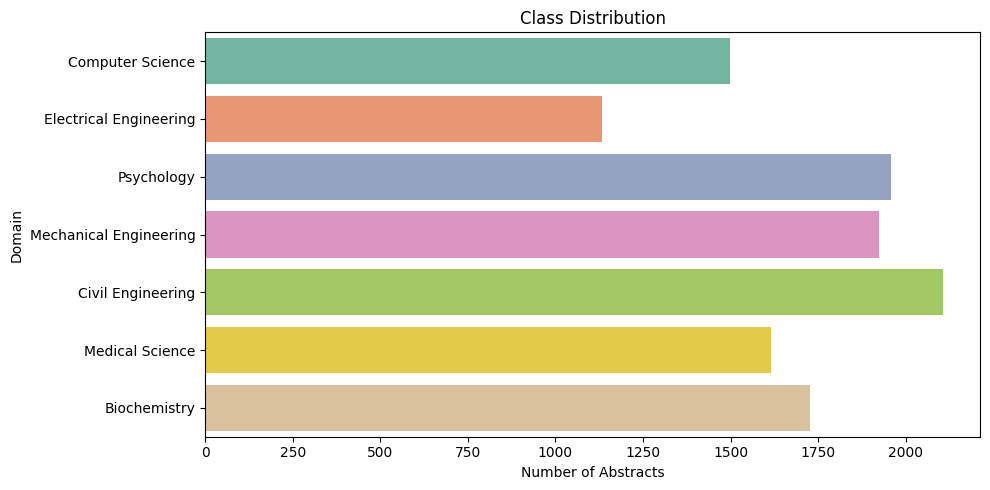

Largest-to-smallest class ratio: 1.86


In [59]:
class_distribution = (
    papers.groupby(["label", "domain"], as_index=False)
    .size()
    .rename(columns={"size": "samples"})
)
class_distribution["percentage"] = class_distribution["samples"] / len(papers) * 100

display(class_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_distribution, x="samples", y="domain", hue="domain", legend=False, palette="Set2")
plt.title("Class Distribution")
plt.xlabel("Number of Abstracts")
plt.ylabel("Domain")
plt.tight_layout()

class_figure_path = FIGURES_DIR / "class_distribution.png"
plt.savefig(class_figure_path, dpi=200, bbox_inches="tight")
plt.show()

imbalance_ratio = class_distribution["samples"].max() / class_distribution["samples"].min()
print("Largest-to-smallest class ratio:", round(imbalance_ratio, 2))


## Abstract Lengths

,count,mean,std,min,25%,50%,75%,95%,99%,max
word_count,11967.0,195.17,70.81,22.0,147.0,189.0,238.0,319.0,407.00,906.0
character_count,11967.0,1340.77,480.75,150.0,1008.0,1299.0,1628.0,2171.0,2761.68,6140.0


,count,mean,median,min,max
domain,,,,,
Biochemistry,1728,208.58,203.0,24,705
Civil Engineering,2107,208.07,201.0,22,715
Computer Science,1499,183.04,174.0,36,572
Electrical Engineering,1132,165.34,163.0,40,552
Mechanical Engineering,1925,186.42,180.0,23,624
Medical Science,1617,221.68,223.0,30,589
Psychology,1959,182.70,171.0,31,906


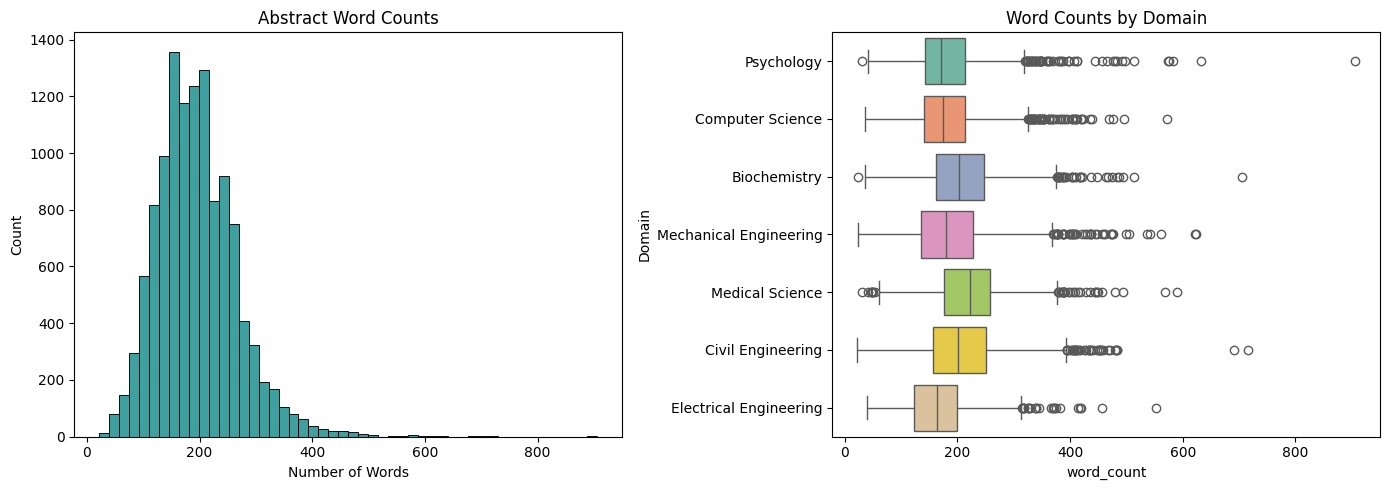

Saved: /kaggle/working/cse440-results/figures/text_length_analysis.png


In [60]:
length_summary = papers[["word_count", "character_count"]].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(length_summary.round(2))
display(papers.groupby("domain")["word_count"].agg(["count", "mean", "median", "min", "max"]).round(2))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(papers["word_count"], bins=50, color="teal", ax=axes[0])
axes[0].set_title("Abstract Word Counts")
axes[0].set_xlabel("Number of Words")

sns.boxplot(data=papers, x="word_count", y="domain", hue="domain", legend=False, palette="Set2", ax=axes[1])
axes[1].set_title("Word Counts by Domain")
axes[1].set_ylabel("Domain")

plt.tight_layout()
length_figure_path = FIGURES_DIR / "text_length_analysis.png"
plt.savefig(length_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", length_figure_path)


## Word Clouds and Representative Examples

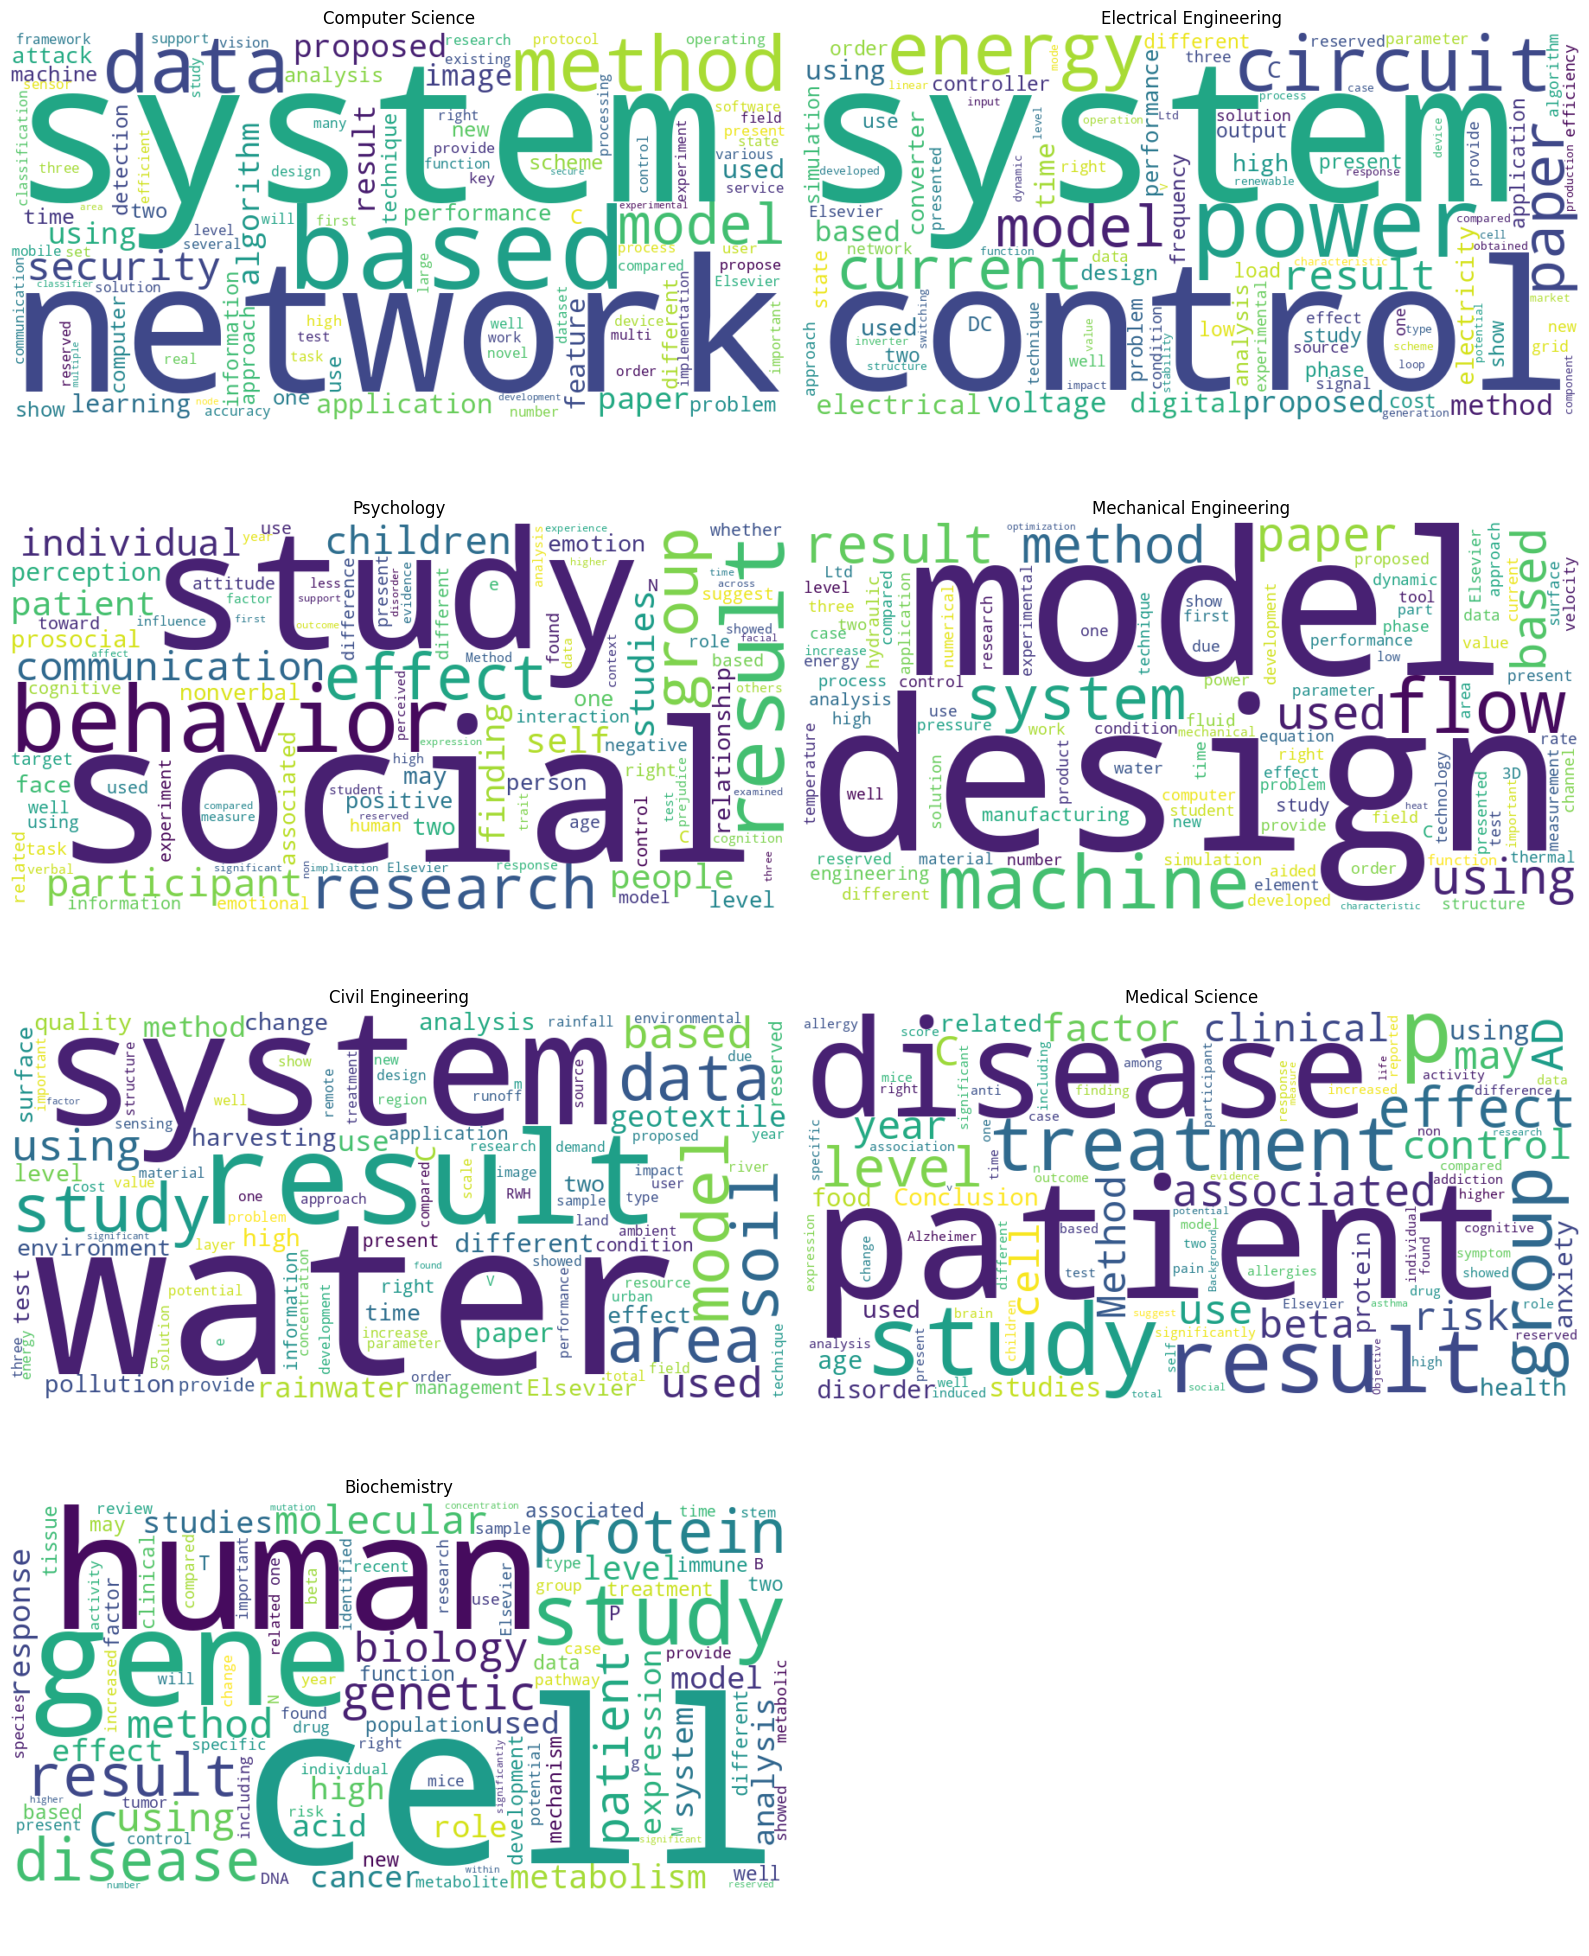

,document_id,domain,word_count,excerpt
0,wos11967_v6_08833,Computer Science,120,Network security situation prediction is of gr...
1,wos11967_v6_11096,Computer Science,157,"Recently, using compressive sensing (CS) as a ..."
2,wos11967_v6_08261,Electrical Engineering,182,Multifunction RF systems which can operate wit...
3,wos11967_v6_09341,Electrical Engineering,132,This paper presents a power system harmonic el...
4,wos11967_v6_07045,Psychology,225,Research on bullying has highlighted the role ...
5,wos11967_v6_03505,Psychology,128,An experiment investigated the effects of viol...
6,wos11967_v6_11444,Mechanical Engineering,173,An analytic model is presented for quantitativ...
7,wos11967_v6_10151,Mechanical Engineering,160,Composites made fromrenewable sources have bec...
8,wos11967_v6_04053,Civil Engineering,260,Research into ambient assisted living (AAL) st...
9,wos11967_v6_09273,Civil Engineering,165,Rainwater harvesting (RWH) plays an important ...


Saved: /kaggle/working/cse440-results/figures/class_wordclouds.png


In [61]:
figure, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for axis, (label, domain) in zip(axes, label_names.items()):
    domain_text = " ".join(papers.loc[papers["label"].eq(label), "text"])
    cloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        stopwords=STOPWORDS,
        max_words=100,
        random_state=SEED,
        collocations=False,
    ).generate(domain_text)
    axis.imshow(cloud, interpolation="bilinear")
    axis.set_title(domain)
    axis.axis("off")

axes[-1].axis("off")
plt.tight_layout()
wordcloud_path = FIGURES_DIR / "class_wordclouds.png"
plt.savefig(wordcloud_path, dpi=180, bbox_inches="tight")
plt.show()

representative_examples = pd.concat([
    class_rows.sample(n=min(2, len(class_rows)), random_state=SEED)
    for _, class_rows in papers.groupby("label", sort=True)
], ignore_index=True)
representative_examples["excerpt"] = representative_examples["text"].str.slice(0, 350)

display(representative_examples[["document_id", "domain", "word_count", "excerpt"]])
print("Saved:", wordcloud_path)


# 5. Preprocessing and Frozen Split

TF-IDF uses lowercase text with safe whitespace normalization. GloVe uses a training-fitted Keras tokenizer. BERT uses its official tokenizer with minimal normalization. No representation is fitted on validation or test text.


## Split Helper

A reproducible 70/15/15 split. Normalized duplicate groups stay together to prevent leakage.

In [62]:
def create_split_manifest(papers):
    split_source = papers.copy()
    split_source["duplicate_group"] = pd.factorize(split_source["normalized_text"])[0]

    if normalized_duplicate_rows > 0:
        splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
        fold_numbers = np.full(len(split_source), -1, dtype=int)

        for fold, (_, held_out_rows) in enumerate(
            splitter.split(
                split_source,
                y=split_source["label"],
                groups=split_source["duplicate_group"],
            )
        ):
            fold_numbers[held_out_rows] = fold

        split_names = np.where(
            fold_numbers < 14,
            "train",
            np.where(fold_numbers < 17, "validation", "test"),
        )
        split_method = "StratifiedGroupKFold"
    else:
        train_rows, remaining_rows = train_test_split(
            split_source.index,
            test_size=0.30,
            random_state=SEED,
            stratify=split_source["label"],
        )
        validation_rows, test_rows = train_test_split(
            remaining_rows,
            test_size=0.50,
            random_state=SEED,
            stratify=split_source.loc[remaining_rows, "label"],
        )

        split_names = np.full(len(split_source), "", dtype=object)
        split_names[train_rows] = "train"
        split_names[validation_rows] = "validation"
        split_names[test_rows] = "test"
        split_method = "Two-stage stratified split"

    split_source["split"] = split_names
    manifest_columns = [
        "document_id",
        "source_row",
        "label",
        "domain",
        "duplicate_group",
        "split",
    ]
    return split_source[manifest_columns].copy(), split_method

## Create or Reload the Split Manifest

In [63]:
manifest_path = WORK_DIR / "split_manifest.csv"

if manifest_path.exists():
    split_manifest = pd.read_csv(manifest_path)
    if set(split_manifest["document_id"]) != set(papers["document_id"]):
        raise ValueError("The saved split manifest does not match the attached dataset.")
    split_method = "Reloaded saved manifest"
else:
    split_manifest, split_method = create_split_manifest(papers)
    split_manifest.to_csv(manifest_path, index=False)

display(split_manifest.groupby(["domain", "split"]).size().unstack(fill_value=0))
print("Split method:", split_method)
print("Saved manifest:", manifest_path)

split,test,train,validation
domain,,,
Biochemistry,259,1210,259
Civil Engineering,316,1475,316
Computer Science,225,1049,225
Electrical Engineering,170,792,170
Mechanical Engineering,289,1347,289
Medical Science,243,1132,242
Psychology,294,1371,294


Split method: Reloaded saved manifest
Saved manifest: /kaggle/working/cse440-results/split_manifest.csv


## Validate and Apply the Split

In [64]:
if exact_conflicts or normalized_conflicts:
    raise ValueError("Conflicting duplicate labels must be reviewed before training.")
if split_manifest["document_id"].duplicated().any():
    raise ValueError("A document appears more than once in the split manifest.")
if split_manifest.groupby("duplicate_group")["split"].nunique().max() > 1:
    raise ValueError("A normalized duplicate group crosses data splits.")
if not split_manifest.groupby("split")["label"].nunique().eq(7).all():
    raise ValueError("Every split must contain all seven classes.")

papers = papers.drop(columns=["split"], errors="ignore").merge(
    split_manifest[["document_id", "split"]],
    on="document_id",
    how="left",
    validate="one_to_one",
)

train_data = papers.loc[papers["split"].eq("train")].reset_index(drop=True)
validation_data = papers.loc[papers["split"].eq("validation")].reset_index(drop=True)
test_data = papers.loc[papers["split"].eq("test")].reset_index(drop=True)

X_train_text = train_data["text"]
X_val_text = validation_data["text"]
X_test_text = test_data["text"]
y_train = train_data["label"].to_numpy()
y_val = validation_data["label"].to_numpy()
y_test = test_data["label"].to_numpy()

split_sizes = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [len(train_data), len(validation_data), len(test_data)],
})
display(split_sizes)
print("Split validation passed. Test labels remain unused until ACTIVE_STAGE is final.")

,Split,Samples
0,Train,8376
1,Validation,1795
2,Test,1796


Split validation passed. Test labels remain unused until ACTIVE_STAGE is final.


## Experiment Results Table

In [65]:
tuning_path = WORK_DIR / "tuning_results.csv"
tuning_columns = [
    "model",
    "family",
    "representation",
    "config_id",
    "hyperparameters",
    "validation_accuracy",
    "validation_macro_f1",
    "best_epoch",
    "training_time_seconds",
    "checkpoint_path",
]

if tuning_path.exists():
    tuning_results = pd.read_csv(tuning_path).reindex(columns=tuning_columns)
else:
    tuning_results = pd.DataFrame(columns=tuning_columns)

print("Existing official tuning runs:", len(tuning_results))
print("Tuning table:", tuning_path)

Existing official tuning runs: 30
Tuning table: /kaggle/working/cse440-results/tuning_results.csv


### Save One Tuning Result

Replacing a repeated model/configuration row before saving, which keeps resumed sessions free of duplicates.

In [66]:
def record_tuning_result(result):
    global tuning_results

    existing_result = (
        tuning_results["model"].eq(result["model"])
        & tuning_results["config_id"].eq(result["config_id"])
    )
    tuning_results = tuning_results.loc[~existing_result].copy()
    tuning_results = pd.concat(
        [tuning_results, pd.DataFrame([result])],
        ignore_index=True,
    )
    tuning_results.to_csv(tuning_path, index=False)

### Validation Metrics

Accuracy and macro-F1

In [67]:
def validation_scores(true_labels, predictions):
    return {
        "validation_accuracy": accuracy_score(true_labels, predictions),
        "validation_macro_f1": f1_score(true_labels, predictions, average="macro"),
    }

## Leakage Assertions

In [68]:
assert len(papers) >= 10000
assert papers["label"].nunique() == 7
assert papers["normalized_text"].ne("").all()
assert set(train_data["document_id"]).isdisjoint(validation_data["document_id"])
assert set(train_data["document_id"]).isdisjoint(test_data["document_id"])
assert set(validation_data["document_id"]).isdisjoint(test_data["document_id"])

print("Pre-training assertions passed.")


Pre-training assertions passed.


# 6. TF-IDF and Traditional Models

Fitting TF-IDF on training abstracts only. Tuning Logistic Regression, Multinomial Naive Bayes, and Random Forest with three manual configurations each.

## TF-IDF Representation

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = None
X_train_tfidf = None
X_val_tfidf = None

if ACTIVE_STAGE in {"traditional", "final"}:
    tfidf_vectorizer = TfidfVectorizer(
        lowercase=True,
        preprocessor=normalize_text,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=50000,
        sublinear_tf=True,
    )
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
    X_val_tfidf = tfidf_vectorizer.transform(X_val_text)
    joblib.dump(tfidf_vectorizer, WORK_DIR / "tfidf_vectorizer.joblib")

    print("Training TF-IDF shape:", X_train_tfidf.shape)
    print("Validation TF-IDF shape:", X_val_tfidf.shape)
else:
    print("TF-IDF fitting is reserved for the traditional or final stage.")

Training TF-IDF shape: (8376, 50000)
Validation TF-IDF shape: (1795, 50000)


## Manual Traditional Configurations

Each required traditional model has exactly three manually selected hyperparameter configurations.

In [70]:
traditional_configurations = [
    {"model": "Logistic Regression", "config_id": "LR_1", "parameters": {"C": 0.5}},
    {"model": "Logistic Regression", "config_id": "LR_2", "parameters": {"C": 1.0}},
    {"model": "Logistic Regression", "config_id": "LR_3", "parameters": {"C": 2.0}},
    {"model": "Multinomial Naive Bayes", "config_id": "NB_1", "parameters": {"alpha": 0.1}},
    {"model": "Multinomial Naive Bayes", "config_id": "NB_2", "parameters": {"alpha": 0.5}},
    {"model": "Multinomial Naive Bayes", "config_id": "NB_3", "parameters": {"alpha": 1.0}},
    {"model": "Random Forest", "config_id": "RF_1", "parameters": {"n_estimators": 200, "max_depth": 50}},
    {"model": "Random Forest", "config_id": "RF_2", "parameters": {"n_estimators": 300, "max_depth": 100}},
    {"model": "Random Forest", "config_id": "RF_3", "parameters": {"n_estimators": 400, "max_depth": None}},
]

display(pd.DataFrame(traditional_configurations))


,model,config_id,parameters
0,Logistic Regression,LR_1,{'C': 0.5}
1,Logistic Regression,LR_2,{'C': 1.0}
2,Logistic Regression,LR_3,{'C': 2.0}
3,Multinomial Naive Bayes,NB_1,{'alpha': 0.1}
4,Multinomial Naive Bayes,NB_2,{'alpha': 0.5}
5,Multinomial Naive Bayes,NB_3,{'alpha': 1.0}
6,Random Forest,RF_1,"{'n_estimators': 200, 'max_depth': 50}"
7,Random Forest,RF_2,"{'n_estimators': 300, 'max_depth': 100}"
8,Random Forest,RF_3,"{'n_estimators': 400, 'max_depth': None}"


## Traditional Model Helpers

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB


def create_traditional_model(model_name, parameters):
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, random_state=SEED, **parameters)
    if model_name == "Multinomial Naive Bayes":
        return MultinomialNB(**parameters)
    if model_name == "Random Forest":
        return RandomForestClassifier(random_state=SEED, n_jobs=-1, **parameters)
    raise ValueError(f"Unknown traditional model: {model_name}")


def train_traditional_model(model_name):
    
    if ACTIVE_STAGE != "traditional":
        model_results = tuning_results.loc[
            tuning_results["model"].eq(model_name)
        ].copy()
    
        print(
            f"Loaded {len(model_results)} saved "
            f"configurations for {model_name}."
        )
    
        display(
            model_results.sort_values(
                "validation_macro_f1",
                ascending=False,
            )
        )
        return

    model_configurations = [
        configuration
        for configuration in traditional_configurations
        if configuration["model"] == model_name
    ]
    completed_runs = set(zip(tuning_results["model"], tuning_results["config_id"]))

    for configuration in model_configurations:
        run_id = configuration["config_id"]
        run_key = (model_name, run_id)
        if run_key in completed_runs:
            print("Skipping completed run:", run_id)
            continue

        model = create_traditional_model(model_name, configuration["parameters"])
        start_time = time.perf_counter()
        model.fit(X_train_tfidf, y_train)
        validation_predictions = model.predict(X_val_tfidf)
        elapsed = time.perf_counter() - start_time

        checkpoint = CHECKPOINTS_DIR / f"{run_id}.joblib"
        joblib.dump(model, checkpoint)
        scores = validation_scores(y_val, validation_predictions)
        record_tuning_result({
            "model": model_name,
            "family": "Traditional",
            "representation": "TF-IDF",
            "config_id": run_id,
            "hyperparameters": json.dumps(configuration["parameters"], sort_keys=True),
            **scores,
            "best_epoch": np.nan,
            "training_time_seconds": elapsed,
            "checkpoint_path": str(checkpoint.relative_to(WORK_DIR)),
        })
        completed_runs.add(run_key)
        print(run_id, scores)

    model_results = tuning_results.loc[tuning_results["model"].eq(model_name)]
    display(model_results.sort_values("validation_macro_f1", ascending=False))

### Logistic Regression

In [72]:
train_traditional_model("Logistic Regression")

Loaded 3 saved configurations for Logistic Regression.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
2,Logistic Regression,Traditional,TF-IDF,LR_3,"{""C"": 2.0}",0.911978,0.910476,NaN,9.661146,checkpoints/LR_3.joblib
1,Logistic Regression,Traditional,TF-IDF,LR_2,"{""C"": 1.0}",0.900836,0.899381,NaN,8.552706,checkpoints/LR_2.joblib
0,Logistic Regression,Traditional,TF-IDF,LR_1,"{""C"": 0.5}",0.886908,0.884617,NaN,6.475947,checkpoints/LR_1.joblib


### Multinomial Naive Bayes

In [73]:
train_traditional_model("Multinomial Naive Bayes")

Loaded 3 saved configurations for Multinomial Naive Bayes.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
3,Multinomial Naive Bayes,Traditional,TF-IDF,NB_1,"{""alpha"": 0.1}",0.849582,0.845728,NaN,0.040789,checkpoints/NB_1.joblib
4,Multinomial Naive Bayes,Traditional,TF-IDF,NB_2,"{""alpha"": 0.5}",0.826184,0.812233,NaN,0.019962,checkpoints/NB_2.joblib
5,Multinomial Naive Bayes,Traditional,TF-IDF,NB_3,"{""alpha"": 1.0}",0.808914,0.787868,NaN,0.019261,checkpoints/NB_3.joblib


### Random Forest

In [74]:
train_traditional_model("Random Forest")

Loaded 3 saved configurations for Random Forest.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
6,Random Forest,Traditional,TF-IDF,RF_1,"{""max_depth"": 50, ""n_estimators"": 200}",0.901950,0.901717,NaN,10.792903,checkpoints/RF_1.joblib
8,Random Forest,Traditional,TF-IDF,RF_3,"{""max_depth"": null, ""n_estimators"": 400}",0.900279,0.901144,NaN,31.184169,checkpoints/RF_3.joblib
7,Random Forest,Traditional,TF-IDF,RF_2,"{""max_depth"": 100, ""n_estimators"": 300}",0.896936,0.897314,NaN,22.786582,checkpoints/RF_2.joblib


# 7. GloVe and Sequence Preparation

Tokenizing the abstracts using the training vocabulary, padding every sequence to the same length, and initializing the embedding layer with GloVe 6B 100-dimensional vectors.

## Tokenize the Abstracts

Fitting the Keras tokenizer on training text only and choosing the sequence length from the training distribution.

In [75]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

NUM_WORDS = 30000
EMBEDDING_DIM = 100

tokenizer = None
sequence_length = None
X_train_seq = None
X_val_seq = None
X_test_seq = None

if ACTIVE_STAGE in {"rnn", "final"}:
    import tensorflow as tf

    tf.keras.utils.set_random_seed(SEED)
    tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>", lower=True)
    tokenizer.fit_on_texts(X_train_text)

    training_lengths = X_train_text.str.split().str.len()
    sequence_length = min(400, int(np.ceil(training_lengths.quantile(0.95))))

    X_train_seq = pad_sequences(
        tokenizer.texts_to_sequences(X_train_text),
        maxlen=sequence_length,
        padding="post",
        truncating="post",
    )
    X_val_seq = pad_sequences(
        tokenizer.texts_to_sequences(X_val_text),
        maxlen=sequence_length,
        padding="post",
        truncating="post",
    )

    if ACTIVE_STAGE == "final":
        X_test_seq = pad_sequences(
            tokenizer.texts_to_sequences(X_test_text),
            maxlen=sequence_length,
            padding="post",
            truncating="post",
        )

    print("Vocabulary entries:", min(NUM_WORDS, len(tokenizer.word_index) + 1))
    print("Sequence length:", sequence_length)
    print("Training sequence shape:", X_train_seq.shape)
else:
    print("GloVe preparation is reserved for the rnn or final stage.")

Vocabulary entries: 30000
Sequence length: 320
Training sequence shape: (8376, 320)


## Load GloVe and Measure Coverage

Loading only vectors needed by the training vocabulary, build the embedding matrix, and report validation coverage.

In [76]:
embedding_matrix = None

if ACTIVE_STAGE in {"rnn", "final"}:
    if not GLOVE_PATH.is_file():
        raise FileNotFoundError(f"Missing GloVe input: {GLOVE_PATH}")

    vocabulary_size = min(NUM_WORDS, len(tokenizer.word_index) + 1)
    needed_words = {
        word
        for word, index in tokenizer.word_index.items()
        if index < vocabulary_size
    }
    glove_vectors = {}

    with GLOVE_PATH.open("r", encoding="utf-8") as glove_file:
        for line in glove_file:
            values = line.rstrip().split()
            word = values[0]
            if word in needed_words:
                glove_vectors[word] = np.asarray(values[1:], dtype="float32")

    rng = np.random.default_rng(SEED)
    embedding_matrix = rng.normal(
        0,
        0.05,
        size=(vocabulary_size, EMBEDDING_DIM),
    ).astype("float32")
    embedding_matrix[0] = 0

    covered_words = 0
    for word, index in tokenizer.word_index.items():
        if index >= vocabulary_size:
            continue
        vector = glove_vectors.get(word)
        if vector is not None:
            embedding_matrix[index] = vector
            covered_words += 1

    vocabulary_coverage = covered_words / max(1, vocabulary_size - 2)
    validation_token_count = np.count_nonzero(X_val_seq)
    validation_oov_count = np.count_nonzero(
        X_val_seq == tokenizer.word_index["<OOV>"]
    )
    validation_oov_rate = validation_oov_count / max(1, validation_token_count)

    coverage_table = pd.DataFrame({
        "Measure": ["GloVe vocabulary coverage", "Validation token OOV rate"],
        "Value": [vocabulary_coverage, validation_oov_rate],
    })
    display(coverage_table)
else:
    print("GloVe vectors were not loaded in this stage.")

,Measure,Value
0,GloVe vocabulary coverage,0.832322
1,Validation token OOV rate,0.031452


# 8. Recurrent Neural Models

Training SimpleRNN, GRU, LSTM, and their bidirectional variants. Every architecture uses the same three manual profiles for a fair comparison.

## Recurrent Configurations

Profiles A, B, and C preserve the original units, dropout, learning rate, and GloVe trainability choices.

In [77]:
recurrent_profiles = {
    "A": {"units": 64, "trainable_glove": False, "dropout": 0.3, "learning_rate": 1e-3},
    "B": {"units": 128, "trainable_glove": False, "dropout": 0.3, "learning_rate": 1e-3},
    "C": {"units": 128, "trainable_glove": True, "dropout": 0.5, "learning_rate": 5e-4},
}
recurrent_models = [
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM",
]

recurrent_configuration_table = pd.DataFrame([
    {"Model": model_name, "Profile": profile_name, **profile}
    for model_name in recurrent_models
    for profile_name, profile in recurrent_profiles.items()
])
display(recurrent_configuration_table)


,Model,Profile,units,trainable_glove,dropout,learning_rate
0,SimpleRNN,A,64,False,0.3,0.0010
1,SimpleRNN,B,128,False,0.3,0.0010
2,SimpleRNN,C,128,True,0.5,0.0005
3,GRU,A,64,False,0.3,0.0010
4,GRU,B,128,False,0.3,0.0010
5,GRU,C,128,True,0.5,0.0005
6,LSTM,A,64,False,0.3,0.0010
7,LSTM,B,128,False,0.3,0.0010
8,LSTM,C,128,True,0.5,0.0005
9,Bidirectional SimpleRNN,A,64,False,0.3,0.0010


## Recurrent Model Builder

In [78]:
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, GRU, LSTM, SimpleRNN
from tensorflow.keras.models import Sequential


def build_recurrent_model(model_name, profile):
    layer_types = {
        "SimpleRNN": SimpleRNN,
        "GRU": GRU,
        "LSTM": LSTM,
    }
    base_name = model_name.replace("Bidirectional ", "")
    recurrent_layer = layer_types[base_name](profile["units"])

    if model_name.startswith("Bidirectional"):
        recurrent_layer = Bidirectional(recurrent_layer)

    model = Sequential([
        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            trainable=profile["trainable_glove"],
            mask_zero=True,
        ),
        recurrent_layer,
        Dropout(profile["dropout"]),
        Dense(7, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=profile["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


print("Recurrent model builder is ready.")

Recurrent model builder is ready.


## Recurrent Callbacks

Using early stopping and keep only the weights from the lowest validation loss.

In [79]:
def make_recurrent_callbacks(checkpoint):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            str(checkpoint),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
        ),
    ]

## Train One Recurrent Configuration

Training one architecture/profile pair, saving its history and best weights, and appending its validation metrics.

In [80]:
def train_recurrent_configuration(model_name, profile_name, profile):
    run_id = f"RNN_{model_name.replace(' ', '_')}_{profile_name}"
    tf.keras.backend.clear_session()

    model = build_recurrent_model(model_name, profile)
    checkpoint = CHECKPOINTS_DIR / f"{run_id}.weights.h5"
    callbacks = make_recurrent_callbacks(checkpoint)

    start_time = time.perf_counter()
    history = model.fit(
        X_train_seq,
        y_train,
        validation_data=(X_val_seq, y_val),
        epochs=15,
        batch_size=64,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed = time.perf_counter() - start_time

    validation_predictions = model.predict(
        X_val_seq,
        batch_size=64,
        verbose=0,
    ).argmax(axis=1)
    scores = validation_scores(y_val, validation_predictions)
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    history_path = HISTORIES_DIR / f"{run_id}.csv"
    pd.DataFrame(history.history).to_csv(history_path, index=False)

    parameters = {"model_name": model_name, "profile": profile_name, **profile}
    record_tuning_result({
        "model": model_name,
        "family": "Recurrent",
        "representation": "GloVe 6B 100d",
        "config_id": profile_name,
        "hyperparameters": json.dumps(parameters, sort_keys=True),
        **scores,
        "best_epoch": best_epoch,
        "training_time_seconds": elapsed,
        "checkpoint_path": str(checkpoint.relative_to(WORK_DIR)),
    })
    print(run_id, scores)

    del model
    gc.collect()

## Resume One Recurrent Architecture

Skipping completed profiles and running only the missing configurations for the selected architecture.

In [81]:
def train_recurrent_model(model_name):
    if ACTIVE_STAGE != "rnn":
        model_results = tuning_results.loc[
            tuning_results["model"].eq(model_name)
        ].copy()
    
        print(
            f"Loaded {len(model_results)} saved "
            f"configurations for {model_name}."
        )
    
        display(
            model_results.sort_values(
                "validation_macro_f1",
                ascending=False,
            )
        )
        return

    completed_runs = set(zip(tuning_results["model"], tuning_results["config_id"]))
    for profile_name, profile in recurrent_profiles.items():
        run_key = (model_name, profile_name)
        if run_key in completed_runs:
            run_id = f"RNN_{model_name.replace(' ', '_')}_{profile_name}"
            print("Skipping completed run:", run_id)
            continue

        train_recurrent_configuration(model_name, profile_name, profile)
        completed_runs.add(run_key)

    model_results = tuning_results.loc[tuning_results["model"].eq(model_name)]
    display(model_results.sort_values("validation_macro_f1", ascending=False))

### SimpleRNN

Train or resume profiles A, B, and C for the SimpleRNN architecture.

In [82]:
train_recurrent_model("SimpleRNN")

Loaded 3 saved configurations for SimpleRNN.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
10,SimpleRNN,Recurrent,GloVe 6B 100d,B,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.491922,0.450986,5.0,28.260609,checkpoints/RNN_SimpleRNN_B.weights.h5
11,SimpleRNN,Recurrent,GloVe 6B 100d,C,"{""dropout"": 0.5, ""learning_rate"": 0.0005, ""mod...",0.488579,0.443816,2.0,20.519401,checkpoints/RNN_SimpleRNN_C.weights.h5
9,SimpleRNN,Recurrent,GloVe 6B 100d,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.456267,0.416428,3.0,21.204371,checkpoints/RNN_SimpleRNN_A.weights.h5


### GRU

Same for the GRU architecture.

In [83]:
train_recurrent_model("GRU")

Loaded 3 saved configurations for GRU.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
12,GRU,Recurrent,GloVe 6B 100d,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.877994,0.877154,13.0,34.418817,checkpoints/RNN_GRU_A.weights.h5
13,GRU,Recurrent,GloVe 6B 100d,B,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.874652,0.873262,9.0,26.618495,checkpoints/RNN_GRU_B.weights.h5
14,GRU,Recurrent,GloVe 6B 100d,C,"{""dropout"": 0.5, ""learning_rate"": 0.0005, ""mod...",0.845125,0.839564,6.0,23.227862,checkpoints/RNN_GRU_C.weights.h5


### LSTM

For the LSTM architecture.

In [84]:
train_recurrent_model("LSTM")

Loaded 3 saved configurations for LSTM.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
16,LSTM,Recurrent,GloVe 6B 100d,B,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.853482,0.851801,15.0,36.468561,checkpoints/RNN_LSTM_B.weights.h5
17,LSTM,Recurrent,GloVe 6B 100d,C,"{""dropout"": 0.5, ""learning_rate"": 0.0005, ""mod...",0.831755,0.827501,11.0,34.622916,checkpoints/RNN_LSTM_C.weights.h5
15,LSTM,Recurrent,GloVe 6B 100d,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.825070,0.820069,15.0,36.494899,checkpoints/RNN_LSTM_A.weights.h5


### Bidirectional SimpleRNN

In [85]:
train_recurrent_model("Bidirectional SimpleRNN")

Loaded 3 saved configurations for Bidirectional SimpleRNN.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
20,Bidirectional SimpleRNN,Recurrent,GloVe 6B 100d,C,"{""dropout"": 0.5, ""learning_rate"": 0.0005, ""mod...",0.703064,0.682158,8.0,76.466415,checkpoints/RNN_Bidirectional_SimpleRNN_C.weig...
19,Bidirectional SimpleRNN,Recurrent,GloVe 6B 100d,B,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.615042,0.599971,3.0,39.206798,checkpoints/RNN_Bidirectional_SimpleRNN_B.weig...
18,Bidirectional SimpleRNN,Recurrent,GloVe 6B 100d,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.580501,0.553739,3.0,35.265726,checkpoints/RNN_Bidirectional_SimpleRNN_A.weig...


### Bidirectional GRU

In [86]:
train_recurrent_model("Bidirectional GRU")

Loaded 3 saved configurations for Bidirectional GRU.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
22,Bidirectional GRU,Recurrent,GloVe 6B 100d,B,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.899164,0.899633,10.0,46.575242,checkpoints/RNN_Bidirectional_GRU_B.weights.h5
21,Bidirectional GRU,Recurrent,GloVe 6B 100d,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.894150,0.892001,12.0,47.957476,checkpoints/RNN_Bidirectional_GRU_A.weights.h5
23,Bidirectional GRU,Recurrent,GloVe 6B 100d,C,"{""dropout"": 0.5, ""learning_rate"": 0.0005, ""mod...",0.855153,0.850080,6.0,34.679957,checkpoints/RNN_Bidirectional_GRU_C.weights.h5


### Bidirectional LSTM

In [87]:
train_recurrent_model("Bidirectional LSTM")

Loaded 3 saved configurations for Bidirectional LSTM.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
24,Bidirectional LSTM,Recurrent,GloVe 6B 100d,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.851253,0.851495,14.0,51.676751,checkpoints/RNN_Bidirectional_LSTM_A.weights.h5
25,Bidirectional LSTM,Recurrent,GloVe 6B 100d,B,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""mode...",0.845125,0.841589,9.0,45.982861,checkpoints/RNN_Bidirectional_LSTM_B.weights.h5
26,Bidirectional LSTM,Recurrent,GloVe 6B 100d,C,"{""dropout"": 0.5, ""learning_rate"": 0.0005, ""mod...",0.822841,0.820735,6.0,37.365537,checkpoints/RNN_Bidirectional_LSTM_C.weights.h5


# 9. BERT Base

Fine tuning `bert-base-uncased` for seven-class abstract classification using three manually selected learning rates.

## BERT Tokenizer and Maximum Length

Loading the BERT tokenizer and choosing the maximum length from the training-token distribution.

In [88]:
from transformers import AutoTokenizer


if ACTIVE_STAGE == "final":
    saved_bert_source = (
        tuning_results.loc[tuning_results["model"].eq("BERT Base")]
        .sort_values(
            ["validation_macro_f1", "validation_accuracy"],
            ascending=[False, False],
        )
        .iloc[0]
    )
    BERT_MODEL_SOURCE = str(WORK_DIR / saved_bert_source["checkpoint_path"])
    if not Path(BERT_MODEL_SOURCE).is_dir():
        raise FileNotFoundError(
            f"Recovered BERT checkpoint was not found: {BERT_MODEL_SOURCE}"
        )
else:
    BERT_MODEL_SOURCE = "bert-base-uncased"
bert_tokenizer = None
bert_max_length = None


if ACTIVE_STAGE in {"bert", "final"}:
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_SOURCE)
    training_token_ids = bert_tokenizer(
        X_train_text.tolist(),
        add_special_tokens=True,
        truncation=False,
    )["input_ids"]
    training_token_lengths = np.array([
        len(token_ids) for token_ids in training_token_ids
    ])
    percentage_over_256 = float(np.mean(training_token_lengths > 256) * 100)
    bert_max_length = 256 if percentage_over_256 <= 5 else 384


    token_length_summary = pd.DataFrame({
        "Measure": [
            "Median",
            "95th percentile",
            "Maximum",
            "Percent over 256",
            "Selected maximum length",
        ],
        "Value": [
            np.median(training_token_lengths),
            np.percentile(training_token_lengths, 95),
            training_token_lengths.max(),
            percentage_over_256,
            bert_max_length,
        ],
    })
    display(token_length_summary)

Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors


,Measure,Value
0,Median,254.000000
1,95th percentile,473.250000
2,Maximum,1119.000000
3,Percent over 256,48.853868
4,Selected maximum length,384.000000


## BERT Dataset

Tokenizing each split with the selected maximum length and returning PyTorch tensors expected by the Hugging Face Trainer.

In [89]:
class BertAbstractDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {key: value[index] for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index], dtype=torch.long)
        return item


def make_bert_dataset(texts, labels):
    encodings = bert_tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=bert_max_length,
        return_tensors="pt",
    )
    return BertAbstractDataset(encodings, np.asarray(labels, dtype=int))

## BERT Metrics

In [90]:
def bert_metrics(prediction_output):
    predictions = np.argmax(prediction_output.predictions, axis=1)
    labels = prediction_output.label_ids
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted"),
    }

## Prepare BERT Splits

In [91]:
bert_train_dataset = None
bert_validation_dataset = None
bert_test_dataset = None

if ACTIVE_STAGE in {"bert", "final"}:
    bert_train_dataset = make_bert_dataset(X_train_text, y_train)
    bert_validation_dataset = make_bert_dataset(X_val_text, y_val)

    if ACTIVE_STAGE == "final":
        bert_test_dataset = make_bert_dataset(X_test_text, y_test)

    print("BERT training samples:", len(bert_train_dataset))
    print("BERT validation samples:", len(bert_validation_dataset))
else:
    print("BERT datasets were not created in this stage.")

BERT training samples: 8376
BERT validation samples: 1795


## Manual BERT Configurations

In [92]:
bert_configurations = [
    {"config_id": "BERT_1", "learning_rate": 1e-5},
    {"config_id": "BERT_2", "learning_rate": 2e-5},
    {"config_id": "BERT_3", "learning_rate": 3e-5},
]

display(pd.DataFrame(bert_configurations))


,config_id,learning_rate
0,BERT_1,0.00001
1,BERT_2,0.00002
2,BERT_3,0.00003


## Build the BERT Trainer

In [93]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments


def build_bert_trainer(configuration):
    run_id = configuration["config_id"]
    output_directory = CHECKPOINTS_DIR / run_id
    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_SOURCE,
        num_labels=7,
    )
    training_arguments = TrainingArguments(
        output_dir=str(output_directory),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=configuration["learning_rate"],
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
    )
    trainer = Trainer(
        model=model,
        args=training_arguments,
        train_dataset=bert_train_dataset,
        eval_dataset=bert_validation_dataset,
        processing_class=bert_tokenizer,
        compute_metrics=bert_metrics,
    )
    return model, trainer, output_directory

## Train One BERT Configuration

Skiping an existing configuration or train it, save the best model, and append its validation metrics.

In [94]:
def train_bert_configuration(configuration):
    run_id = configuration["config_id"]
    run_key = ("BERT Base", run_id)
    completed_runs = set(zip(tuning_results["model"], tuning_results["config_id"]))

    if run_key in completed_runs:
        print("Skipping completed run:", run_id)
        return

    model, trainer, output_directory = build_bert_trainer(configuration)

    start_time = time.perf_counter()
    trainer.train()
    elapsed = time.perf_counter() - start_time

    validation_output = trainer.predict(bert_validation_dataset)
    validation_predictions = validation_output.predictions.argmax(axis=1)
    scores = validation_scores(y_val, validation_predictions)

    evaluation_logs = [
        entry
        for entry in trainer.state.log_history
        if "eval_macro_f1" in entry
    ]
    best_log = max(evaluation_logs, key=lambda entry: entry["eval_macro_f1"])
    best_epoch = int(round(best_log["epoch"]))

    best_model_directory = output_directory / "best_model"
    trainer.save_model(best_model_directory)
    bert_tokenizer.save_pretrained(best_model_directory)

    parameters = {
        "learning_rate": configuration["learning_rate"],
        "batch_size": 8,
        "epochs": 3,
        "weight_decay": 0.01,
        "max_length": bert_max_length,
    }
    record_tuning_result({
        "model": "BERT Base",
        "family": "Transformer",
        "representation": "BERT WordPiece",
        "config_id": run_id,
        "hyperparameters": json.dumps(parameters, sort_keys=True),
        **scores,
        "best_epoch": best_epoch,
        "training_time_seconds": elapsed,
        "checkpoint_path": str(best_model_directory.relative_to(WORK_DIR)),
    })
    print(run_id, scores)

    del trainer, model
    gc.collect()

## Train and Validate BERT

In [95]:
if ACTIVE_STAGE == "bert":
    for configuration in bert_configurations:
        train_bert_configuration(configuration)

bert_results = tuning_results.loc[
    tuning_results["model"].eq("BERT Base")
].copy()

if ACTIVE_STAGE != "bert":
    print(
        "Loaded saved BERT validation results; "
        "BERT was not retrained."
    )

display(
    bert_results.sort_values(
        "validation_macro_f1",
        ascending=False,
    )
)

Loaded saved BERT validation results; BERT was not retrained.


,model,family,representation,config_id,hyperparameters,validation_accuracy,validation_macro_f1,best_epoch,training_time_seconds,checkpoint_path
29,BERT Base,Transformer,BERT WordPiece,BERT_3,"{""batch_size"": 8, ""epochs"": 3, ""learning_rate""...",0.945961,0.945496,3.0,1235.439535,checkpoints/BERT_3/best_model
28,BERT Base,Transformer,BERT WordPiece,BERT_2,"{""batch_size"": 8, ""epochs"": 3, ""learning_rate""...",0.942618,0.942426,3.0,1234.593972,checkpoints/BERT_2/best_model
27,BERT Base,Transformer,BERT WordPiece,BERT_1,"{""batch_size"": 8, ""epochs"": 3, ""learning_rate""...",0.930362,0.930503,3.0,1242.084799,checkpoints/BERT_1/best_model


# 10. Validation Results and Selection

The best configuration of each required model is selected by validation macro-F1. Validation accuracy breaks an exact tie.


## Verify the 30 Official Runs



In [96]:
required_models = [
    "Logistic Regression",
    "Multinomial Naive Bayes",
    "Random Forest",
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM",
    "BERT Base",
]

run_counts = (
    tuning_results.groupby("model")
    .size()
    .reindex(required_models, fill_value=0)
    .rename("Completed configurations")
    .reset_index()
    .rename(columns={"model": "Model"})
)
display(run_counts)
print("Total completed official runs:", len(tuning_results))

,Model,Completed configurations
0,Logistic Regression,3
1,Multinomial Naive Bayes,3
2,Random Forest,3
3,SimpleRNN,3
4,GRU,3
5,LSTM,3
6,Bidirectional SimpleRNN,3
7,Bidirectional GRU,3
8,Bidirectional LSTM,3
9,BERT Base,3


Total completed official runs: 30


## Complete Hyperparameter Tuning Results

The following table records all three manually tested configurations for each of the ten required models. Validation macro-F1 was used as the primary model-selection metric, with validation accuracy used as a tie-breaker.

In [97]:
tuning_path = WORK_DIR / "tuning_results.csv"

if not tuning_path.is_file():
    raise FileNotFoundError(
        f"Saved tuning results were not found: {tuning_path}"
    )

tuning_results = pd.read_csv(tuning_path)

display_columns = [
    "model",
    "config_id",
    "hyperparameters",
    "validation_accuracy",
    "validation_macro_f1",
    "training_time_seconds",
    "best_epoch",
]

if len(tuning_results) != 30:
    raise RuntimeError(
        f"Expected 30 tuning runs, but found {len(tuning_results)}."
    )

tuning_table = tuning_results[display_columns].copy()

tuning_table["validation_accuracy"] = (
    tuning_table["validation_accuracy"] * 100
).map(lambda value: f"{value:.2f}%")

tuning_table["validation_macro_f1"] = (
    tuning_table["validation_macro_f1"] * 100
).map(lambda value: f"{value:.2f}%")

tuning_table["training_time_seconds"] = (
    tuning_table["training_time_seconds"]
    .map(lambda value: f"{value:.2f}")
)

tuning_table["best_epoch"] = (
    pd.to_numeric(
        tuning_table["best_epoch"],
        errors="coerce",
    )
    .map(
        lambda value:
        "N/A" if pd.isna(value) else str(int(value))
    )
)

tuning_table = tuning_table.rename(
    columns={
        "model": "Model",
        "config_id": "Configuration",
        "hyperparameters": "Hyperparameters",
        "validation_accuracy": "Validation Accuracy",
        "validation_macro_f1": "Validation Macro-F1",
        "training_time_seconds": "Training Time (seconds)",
        "best_epoch": "Best Epoch",
    }
)

with pd.option_context(
    "display.max_rows", 30,
    "display.max_columns", None,
    "display.max_colwidth", None,
):
    display(tuning_table)

print("Loaded from:", tuning_path)
print("Total tuning runs displayed:", len(tuning_table))

,Model,Configuration,Hyperparameters,Validation Accuracy,Validation Macro-F1,Training Time (seconds),Best Epoch
0,Logistic Regression,LR_1,"{""C"": 0.5}",88.69%,88.46%,6.48,N/A
1,Logistic Regression,LR_2,"{""C"": 1.0}",90.08%,89.94%,8.55,N/A
2,Logistic Regression,LR_3,"{""C"": 2.0}",91.20%,91.05%,9.66,N/A
3,Multinomial Naive Bayes,NB_1,"{""alpha"": 0.1}",84.96%,84.57%,0.04,N/A
4,Multinomial Naive Bayes,NB_2,"{""alpha"": 0.5}",82.62%,81.22%,0.02,N/A
5,Multinomial Naive Bayes,NB_3,"{""alpha"": 1.0}",80.89%,78.79%,0.02,N/A
6,Random Forest,RF_1,"{""max_depth"": 50, ""n_estimators"": 200}",90.19%,90.17%,10.79,N/A
7,Random Forest,RF_2,"{""max_depth"": 100, ""n_estimators"": 300}",89.69%,89.73%,22.79,N/A
8,Random Forest,RF_3,"{""max_depth"": null, ""n_estimators"": 400}",90.03%,90.11%,31.18,N/A
9,SimpleRNN,A,"{""dropout"": 0.3, ""learning_rate"": 0.001, ""model_name"": ""SimpleRNN"", ""profile"": ""A"", ""trainable_glove"": false, ""units"": 64}",45.63%,41.64%,21.20,3


Loaded from: /kaggle/working/cse440-results/tuning_results.csv
Total tuning runs displayed: 30


## Lock the Best Configuration per Model

In [98]:
selected_path = WORK_DIR / "selected_configurations.csv"
selected_configurations = pd.DataFrame()

if ACTIVE_STAGE == "final":
    if len(tuning_results) != 30 or not run_counts["Completed configurations"].eq(3).all():
        raise RuntimeError("Complete exactly three validation runs for every required model before final testing.")

    selected_configurations = (
        tuning_results.sort_values(
            ["model", "validation_macro_f1", "validation_accuracy"],
            ascending=[True, False, False],
        )
        .groupby("model", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    selected_configurations.to_csv(selected_path, index=False)
    display(selected_configurations[[
        "model", "representation", "config_id",
        "validation_accuracy", "validation_macro_f1",
    ]])
    print("Locked configurations:", selected_path)
else:
    print("Configuration locking occurs only in the final stage.")


,model,representation,config_id,validation_accuracy,validation_macro_f1
0,BERT Base,BERT WordPiece,BERT_3,0.945961,0.945496
1,Bidirectional GRU,GloVe 6B 100d,B,0.899164,0.899633
2,Bidirectional LSTM,GloVe 6B 100d,A,0.851253,0.851495
3,Bidirectional SimpleRNN,GloVe 6B 100d,C,0.703064,0.682158
4,GRU,GloVe 6B 100d,A,0.877994,0.877154
5,LSTM,GloVe 6B 100d,B,0.853482,0.851801
6,Logistic Regression,TF-IDF,LR_3,0.911978,0.910476
7,Multinomial Naive Bayes,TF-IDF,NB_1,0.849582,0.845728
8,Random Forest,TF-IDF,RF_1,0.901950,0.901717
9,SimpleRNN,GloVe 6B 100d,B,0.491922,0.450986


Locked configurations: /kaggle/working/cse440-results/selected_configurations.csv


# 11. Final Test Evaluation and Error Analysis

## Final Results Table

In [99]:
final_results_path = WORK_DIR / "final_test_results.csv"

if final_results_path.exists():
    final_test_results = pd.read_csv(final_results_path)
else:
    final_test_results = pd.DataFrame()

completed_test_models = set(
    final_test_results.get("model", pd.Series(dtype=str))
)


def record_final_result(result):
    global final_test_results

    if not final_test_results.empty:
        final_test_results = final_test_results.loc[
            final_test_results["model"].ne(result["model"])
        ].copy()

    final_test_results = pd.concat(
        [final_test_results, pd.DataFrame([result])],
        ignore_index=True,
    )
    final_test_results = final_test_results.sort_values(
        "macro_f1",
        ascending=False,
    ).reset_index(drop=True)
    final_test_results.to_csv(final_results_path, index=False)

## Classification Report Helper

In [100]:
def model_slug(model_name):
    return re.sub(r"[^a-z0-9]+", "_", model_name.lower()).strip("_")


def create_classification_report(model_name, true_labels, predictions):
    label_order = list(label_names)
    target_names = [label_names[label] for label in label_order]
    report = classification_report(
        true_labels,
        predictions,
        labels=label_order,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    report_frame = pd.DataFrame(report).T
    slug = model_slug(model_name)
    report_frame.to_csv(REPORTS_DIR / f"{slug}_classification_report.csv")
    return report_frame, label_order, target_names

## Confusion Matrix Helper

In [101]:
def plot_confusion_matrices(model_name, true_labels, predictions, label_order, target_names):
    slug = model_slug(model_name)
    raw_matrix = confusion_matrix(true_labels, predictions, labels=label_order)
    normalized_matrix = confusion_matrix(
        true_labels,
        predictions,
        labels=label_order,
        normalize="true",
    )

    figure, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(
        raw_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=axes[0],
    )
    axes[0].set_title(f"{model_name}: Raw Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(
        normalized_matrix,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=axes[1],
    )
    axes[1].set_title(f"{model_name}: Row-Normalized Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"{slug}_confusion_matrices.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


print("Evaluation report and plotting helpers are ready.")

Evaluation report and plotting helpers are ready.


## Save One Test Evaluation

In [102]:
def save_test_evaluation(model_name, representation, true_labels, predictions, selected_row):
    report_frame, label_order, target_names = create_classification_report(
        model_name,
        true_labels,
        predictions,
    )
    plot_confusion_matrices(
        model_name,
        true_labels,
        predictions,
        label_order,
        target_names,
    )

    slug = model_slug(model_name)
    prediction_frame = pd.DataFrame({
        "document_id": test_data["document_id"],
        "true_label": np.asarray(true_labels),
        "predicted_label": np.asarray(predictions),
    })
    prediction_frame.to_csv(PREDICTIONS_DIR / f"{slug}.csv", index=False)

    display(report_frame)
    return {
        "model": model_name,
        "representation": representation,
        "config_id": selected_row["config_id"],
        "accuracy": accuracy_score(true_labels, predictions),
        "macro_f1": f1_score(true_labels, predictions, average="macro"),
        "weighted_f1": f1_score(true_labels, predictions, average="weighted"),
        "training_time_seconds": selected_row["training_time_seconds"],
    }

## Evaluate Locked Traditional Models

In [103]:
if ACTIVE_STAGE == "final":
    X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

    traditional_models = [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Random Forest",
    ]
    for model_name in traditional_models:
        if model_name in completed_test_models:
            print("Skipping completed test evaluation:", model_name)
            continue

        selected_row = selected_configurations.loc[
            selected_configurations["model"].eq(model_name)
        ].iloc[0]
        checkpoint = WORK_DIR / selected_row["checkpoint_path"]
        model = joblib.load(checkpoint)
        predictions = model.predict(X_test_tfidf)

        result = save_test_evaluation(
            model_name,
            "TF-IDF",
            y_test,
            predictions,
            selected_row,
        )
        record_final_result(result)
        completed_test_models.add(model_name)
else:
    print("Traditional test evaluation is reserved for the final stage.")

Skipping completed test evaluation: Logistic Regression
Skipping completed test evaluation: Multinomial Naive Bayes
Skipping completed test evaluation: Random Forest


## Evaluate Locked Recurrent Models

In [104]:
if ACTIVE_STAGE == "final":
    import tensorflow as tf

    for model_name in recurrent_models:
        if model_name in completed_test_models:
            print("Skipping completed test evaluation:", model_name)
            continue

        selected_row = selected_configurations.loc[
            selected_configurations["model"].eq(model_name)
        ].iloc[0]
        parameters = json.loads(selected_row["hyperparameters"])
        profile = {
            "units": parameters["units"],
            "trainable_glove": parameters["trainable_glove"],
            "dropout": parameters["dropout"],
            "learning_rate": parameters["learning_rate"],
        }

        tf.keras.backend.clear_session()
        model = build_recurrent_model(model_name, profile)
        model.build((None, sequence_length))

        checkpoint = WORK_DIR / selected_row["checkpoint_path"]
        model.load_weights(checkpoint)
        predictions = model.predict(
            X_test_seq,
            batch_size=64,
            verbose=0,
        ).argmax(axis=1)

        result = save_test_evaluation(
            model_name,
            "GloVe 6B 100d",
            y_test,
            predictions,
            selected_row,
        )
        record_final_result(result)
        completed_test_models.add(model_name)
        del model

    tf.keras.backend.clear_session()
    gc.collect()
else:
    print("Recurrent test evaluation is reserved for the final stage.")

Skipping completed test evaluation: SimpleRNN
Skipping completed test evaluation: GRU
Skipping completed test evaluation: LSTM
Skipping completed test evaluation: Bidirectional SimpleRNN
Skipping completed test evaluation: Bidirectional GRU
Skipping completed test evaluation: Bidirectional LSTM


## Evaluate Locked BERT

Reload the selected BERT checkpoint and evaluate it once on the test dataset.

In [105]:
if ACTIVE_STAGE == "final":
    from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

    if "BERT Base" in completed_test_models:
        print("Skipping completed test evaluation: BERT Base")
    else:
        selected_row = selected_configurations.loc[
            selected_configurations["model"].eq("BERT Base")
        ].iloc[0]
        bert_checkpoint = WORK_DIR / selected_row["checkpoint_path"]
        bert_model = AutoModelForSequenceClassification.from_pretrained(bert_checkpoint)

        prediction_arguments = TrainingArguments(
            output_dir=str(WORK_DIR / "bert_final_prediction"),
            per_device_eval_batch_size=8,
            fp16=torch.cuda.is_available(),
            report_to="none",
        )
        bert_trainer = Trainer(model=bert_model, args=prediction_arguments)
        bert_output = bert_trainer.predict(bert_test_dataset)
        bert_predictions = bert_output.predictions.argmax(axis=1)

        result = save_test_evaluation(
            "BERT Base",
            "BERT WordPiece",
            y_test,
            bert_predictions,
            selected_row,
        )
        record_final_result(result)
        completed_test_models.add("BERT Base")
else:
    print("BERT test evaluation is reserved for the final stage.")

Skipping completed test evaluation: BERT Base


## Verify Final Test Completion

In [106]:
if ACTIVE_STAGE == "final":
    if set(final_test_results["model"]) != set(required_models):
        raise RuntimeError(
            "Final evaluation is incomplete; resume the final stage without changing selections."
        )
    display(final_test_results)
else:
    print("Final completion is checked only during the final stage.")

,model,representation,config_id,accuracy,macro_f1,weighted_f1,training_time_seconds
0,BERT Base,BERT WordPiece,BERT_3,0.951559,0.950603,0.951550,1235.439535
1,Bidirectional GRU,GloVe 6B 100d,B,0.905902,0.905628,0.906365,46.575242
2,Logistic Regression,TF-IDF,LR_3,0.905902,0.902714,0.905592,9.661146
3,Random Forest,TF-IDF,RF_1,0.896437,0.895826,0.896083,10.792903
4,GRU,GloVe 6B 100d,A,0.876392,0.875636,0.876932,34.418817
5,Bidirectional LSTM,GloVe 6B 100d,A,0.852450,0.851396,0.853610,51.676751
6,LSTM,GloVe 6B 100d,B,0.848552,0.847593,0.849154,36.468561
7,Multinomial Naive Bayes,TF-IDF,NB_1,0.842428,0.835756,0.840855,0.040789
8,Bidirectional SimpleRNN,GloVe 6B 100d,C,0.729955,0.713554,0.725765,76.466415
9,SimpleRNN,GloVe 6B 100d,B,0.484410,0.443795,0.465582,28.260609


## Complete Classification Reports and Confusion Matrices

### Logistic Regression

,precision,recall,f1-score,support
Computer Science,0.8952,0.9111,0.9031,225.0000
Electrical Engineering,0.9351,0.8471,0.8889,170.0000
Psychology,0.9178,0.9490,0.9331,294.0000
Mechanical Engineering,0.9397,0.9170,0.9282,289.0000
Civil Engineering,0.9009,0.9494,0.9245,316.0000
Medical Science,0.8602,0.8354,0.8476,243.0000
Biochemistry,0.8953,0.8919,0.8936,259.0000
accuracy,0.9059,0.9059,0.9059,0.9059
macro avg,0.9063,0.9001,0.9027,1796.0000
weighted avg,0.9061,0.9059,0.9056,1796.0000


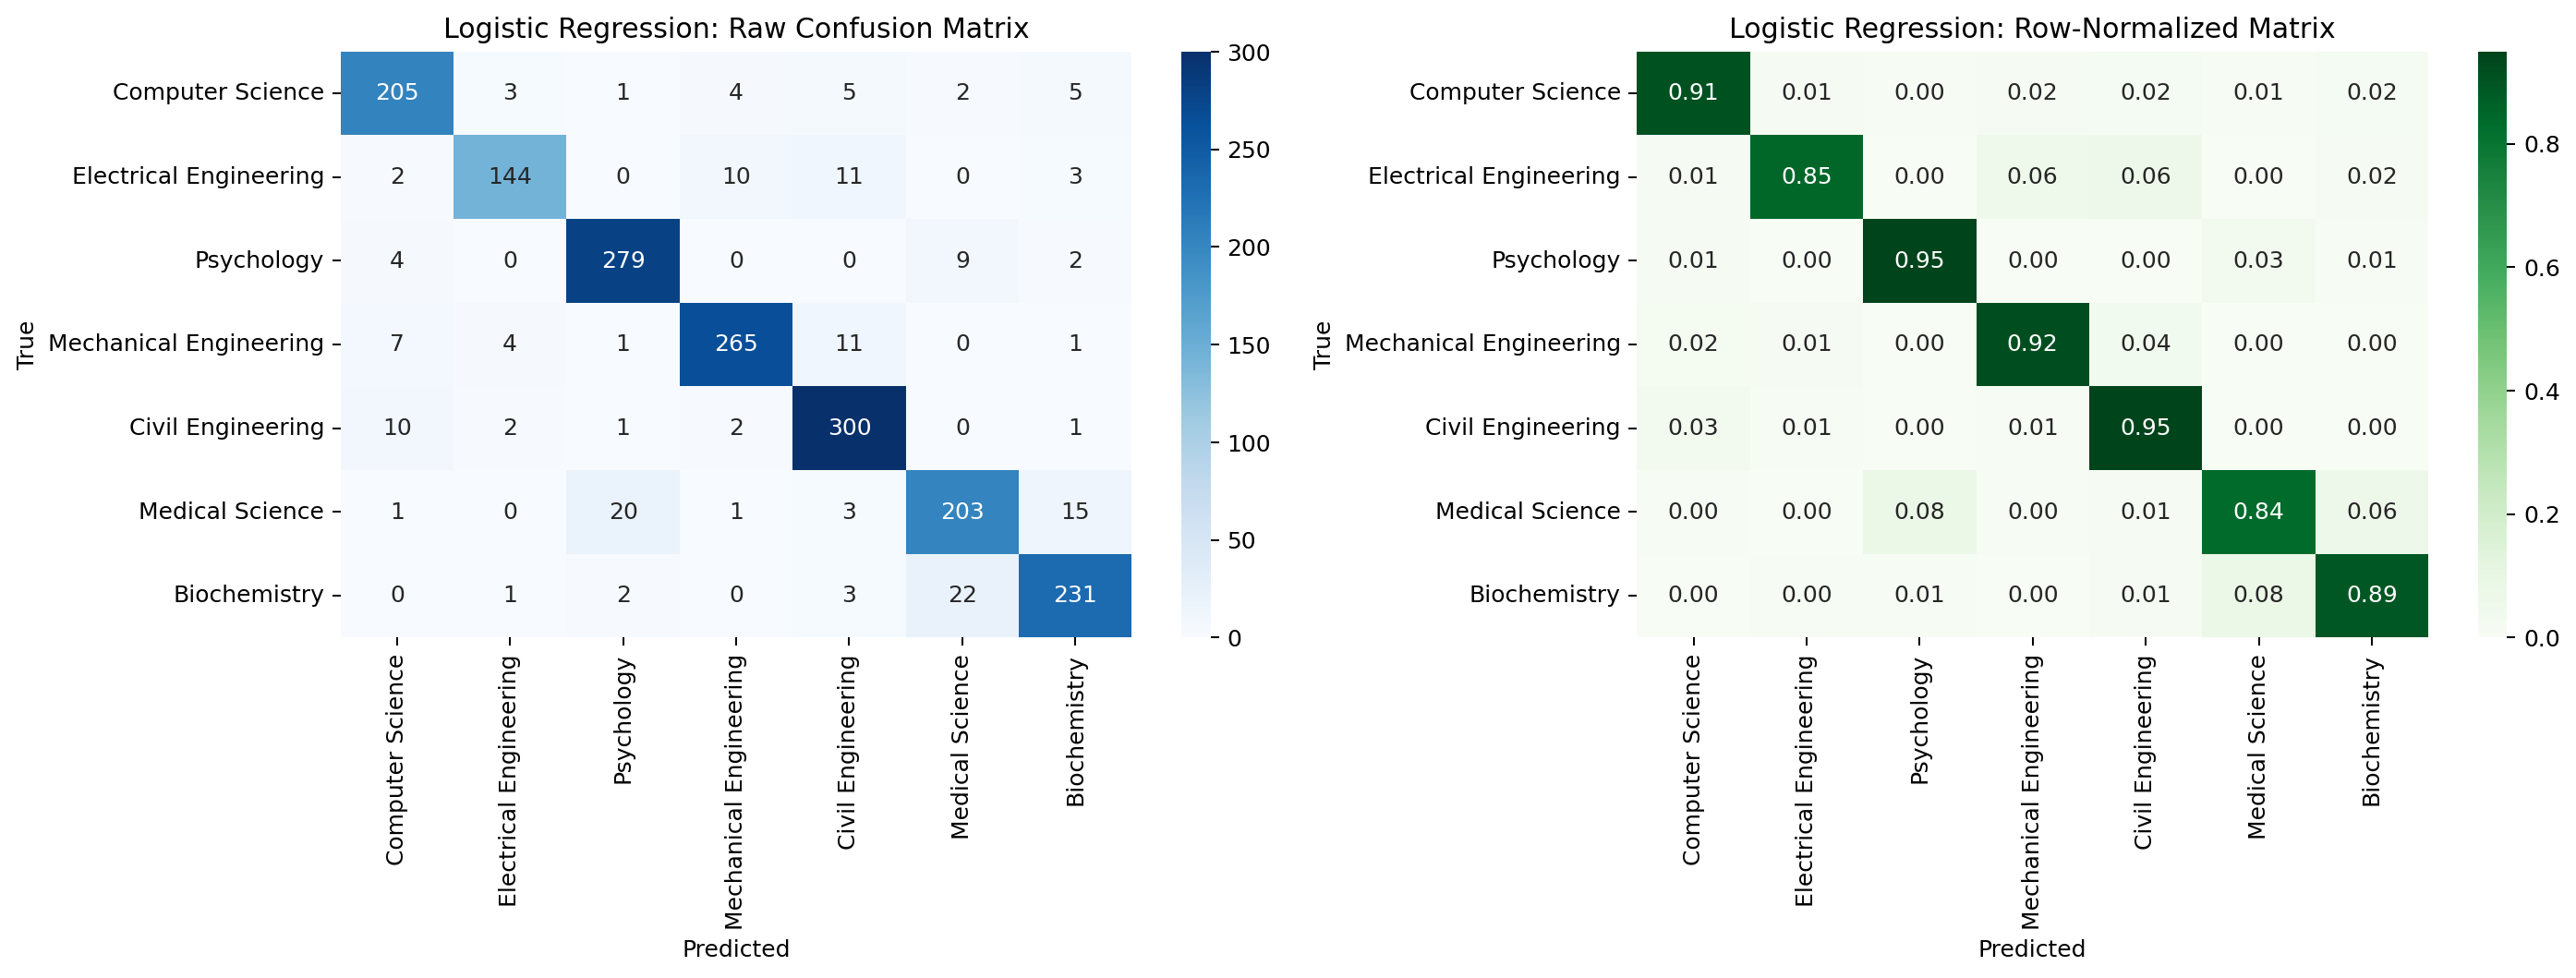

### Multinomial Naive Bayes

,precision,recall,f1-score,support
Computer Science,0.7833,0.9156,0.8443,225.0000
Electrical Engineering,0.8947,0.7000,0.7855,170.0000
Psychology,0.8692,0.9490,0.9073,294.0000
Mechanical Engineering,0.8612,0.8374,0.8491,289.0000
Civil Engineering,0.8431,0.8671,0.8549,316.0000
Medical Science,0.8174,0.7366,0.7749,243.0000
Biochemistry,0.8425,0.8263,0.8343,259.0000
accuracy,0.8424,0.8424,0.8424,0.8424
macro avg,0.8445,0.8331,0.8358,1796.0000
weighted avg,0.8441,0.8424,0.8409,1796.0000


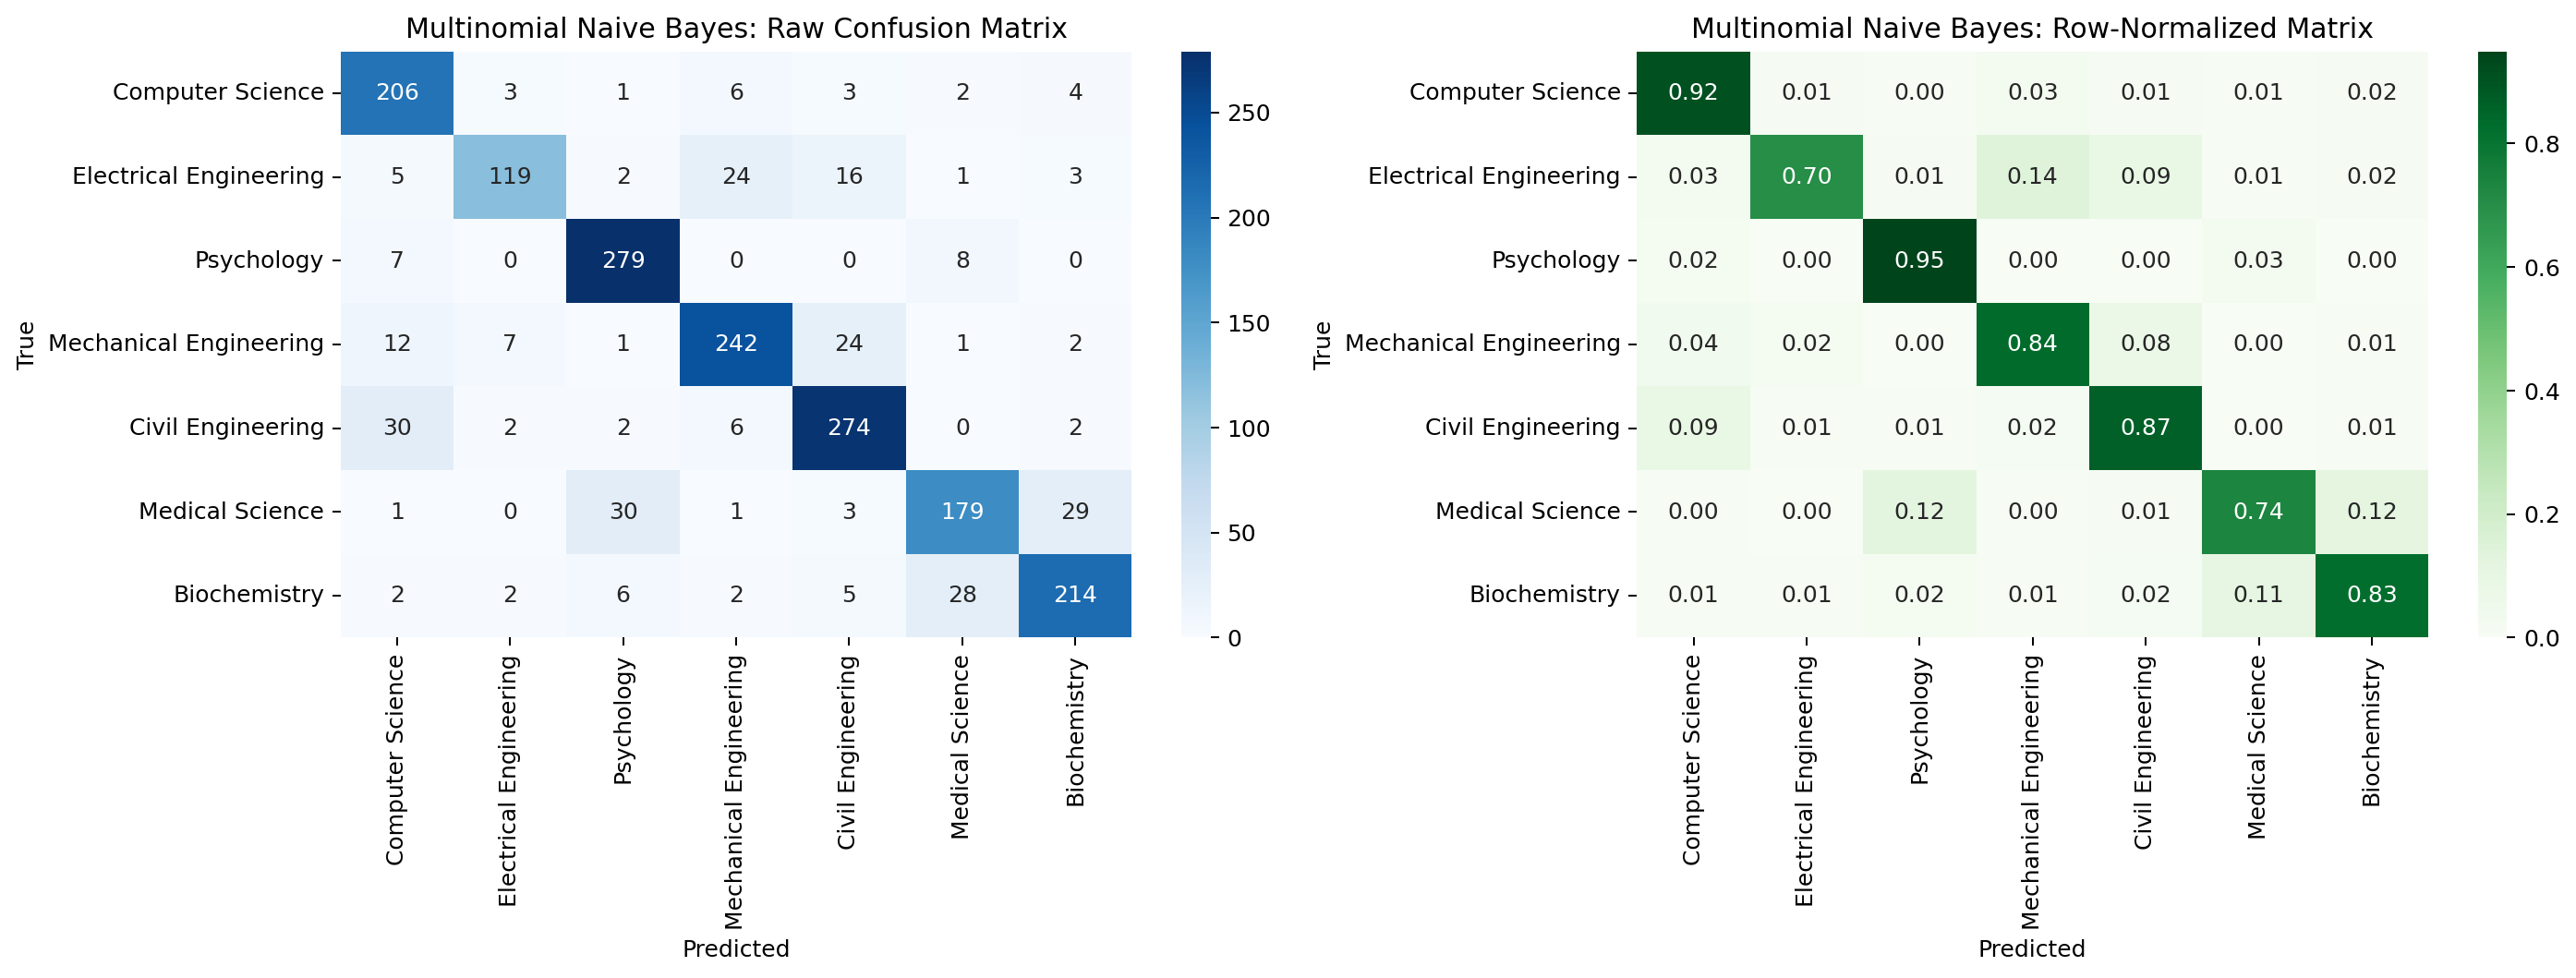

### Random Forest

,precision,recall,f1-score,support
Computer Science,0.9123,0.9244,0.9183,225.0000
Electrical Engineering,0.9865,0.8588,0.9182,170.0000
Psychology,0.8650,0.9592,0.9097,294.0000
Mechanical Engineering,0.9458,0.9066,0.9258,289.0000
Civil Engineering,0.8754,0.9335,0.9035,316.0000
Medical Science,0.8370,0.7819,0.8085,243.0000
Biochemistry,0.8972,0.8764,0.8867,259.0000
accuracy,0.8964,0.8964,0.8964,0.8964
macro avg,0.9028,0.8916,0.8958,1796.0000
weighted avg,0.8981,0.8964,0.8961,1796.0000


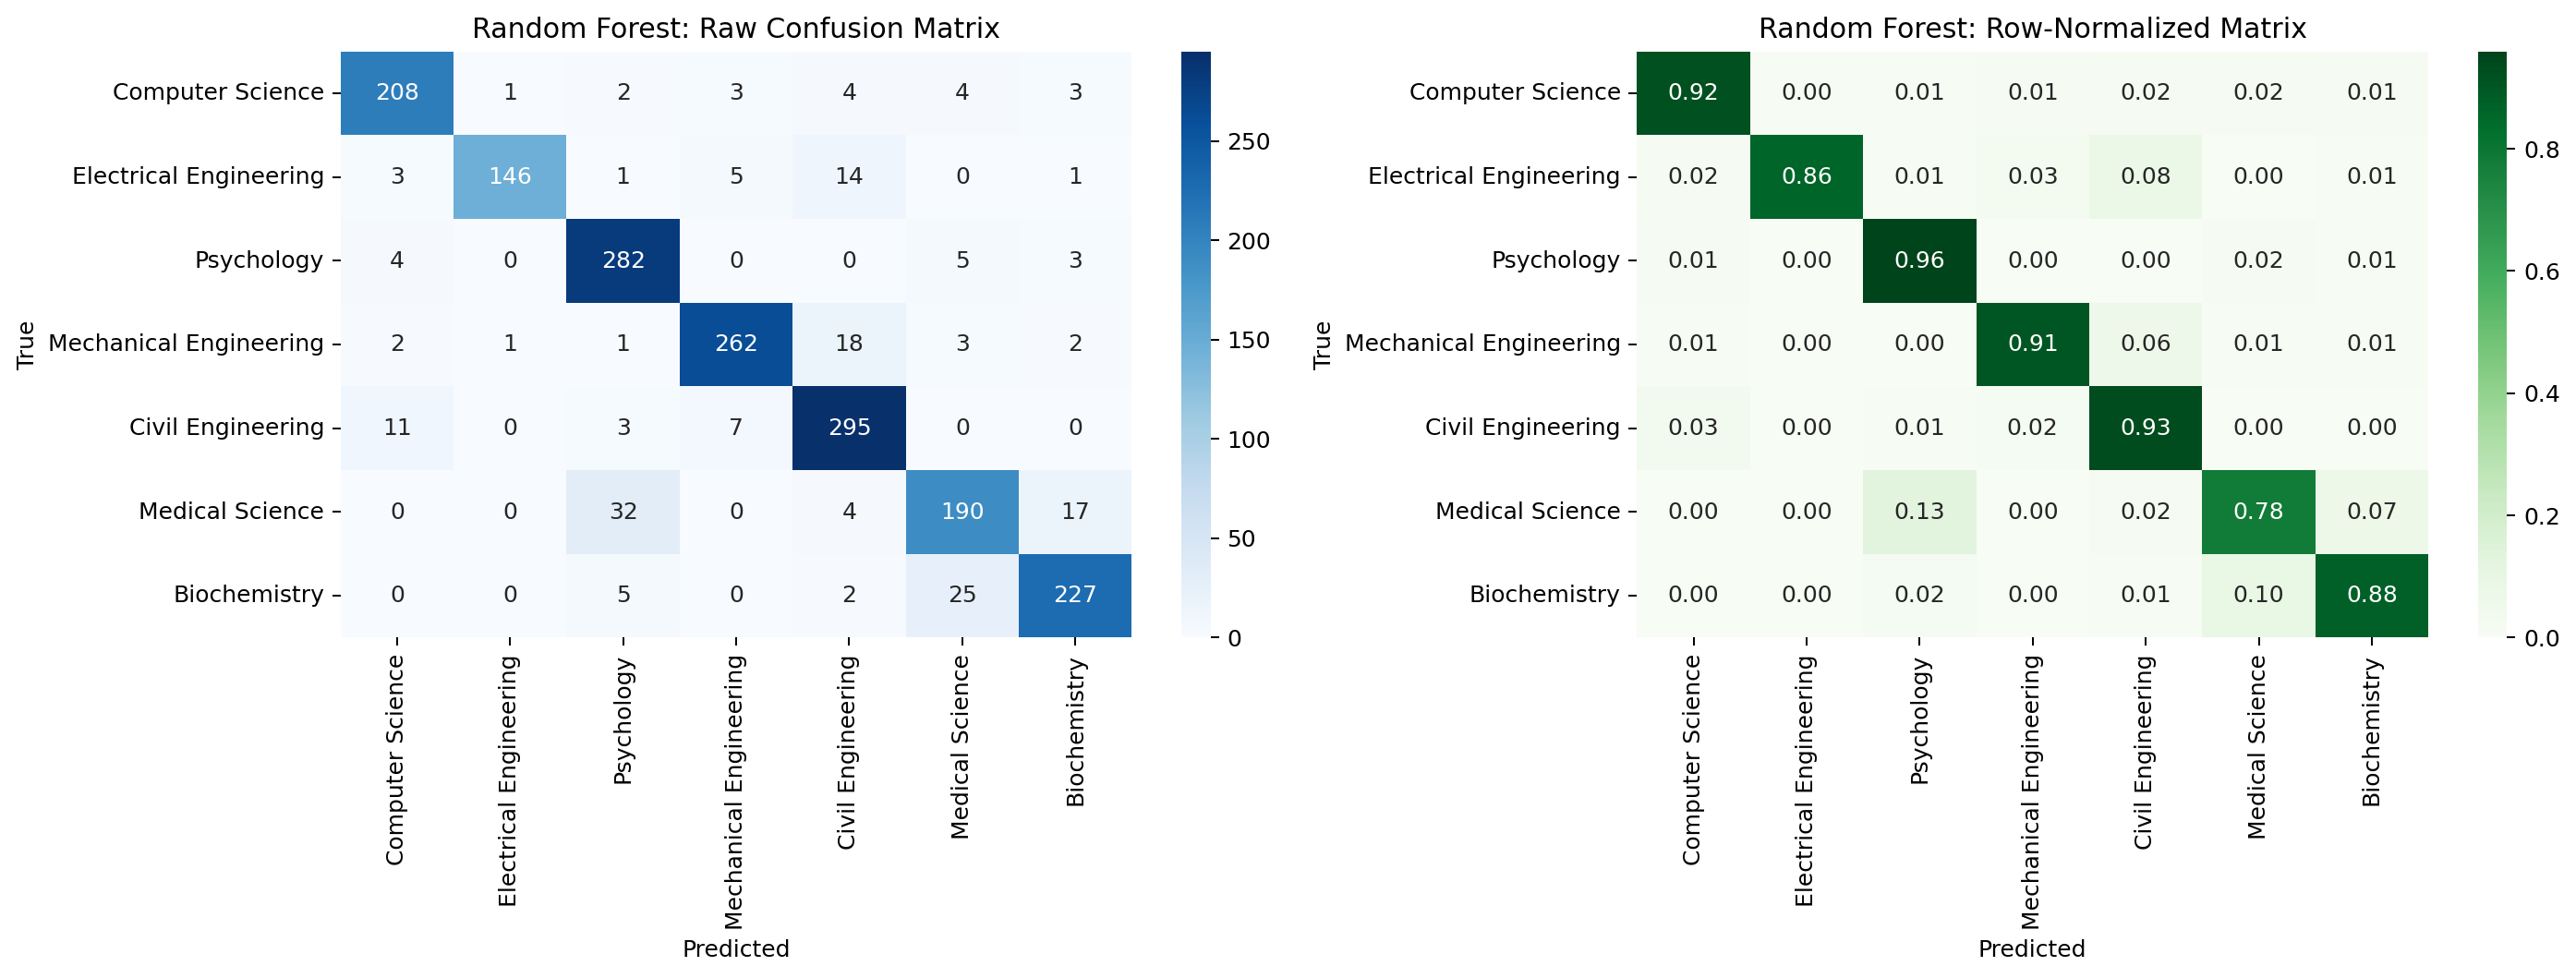

### SimpleRNN

,precision,recall,f1-score,support
Computer Science,0.3923,0.2267,0.2873,225.0000
Electrical Engineering,0.4419,0.1118,0.1784,170.0000
Psychology,0.8245,0.6871,0.7495,294.0000
Mechanical Engineering,0.4310,0.3460,0.3839,289.0000
Civil Engineering,0.4018,0.5506,0.4646,316.0000
Medical Science,0.4101,0.4691,0.4376,243.0000
Biochemistry,0.4828,0.8108,0.6052,259.0000
accuracy,0.4844,0.4844,0.4844,0.4844
macro avg,0.4835,0.4574,0.4438,1796.0000
weighted avg,0.4911,0.4844,0.4656,1796.0000


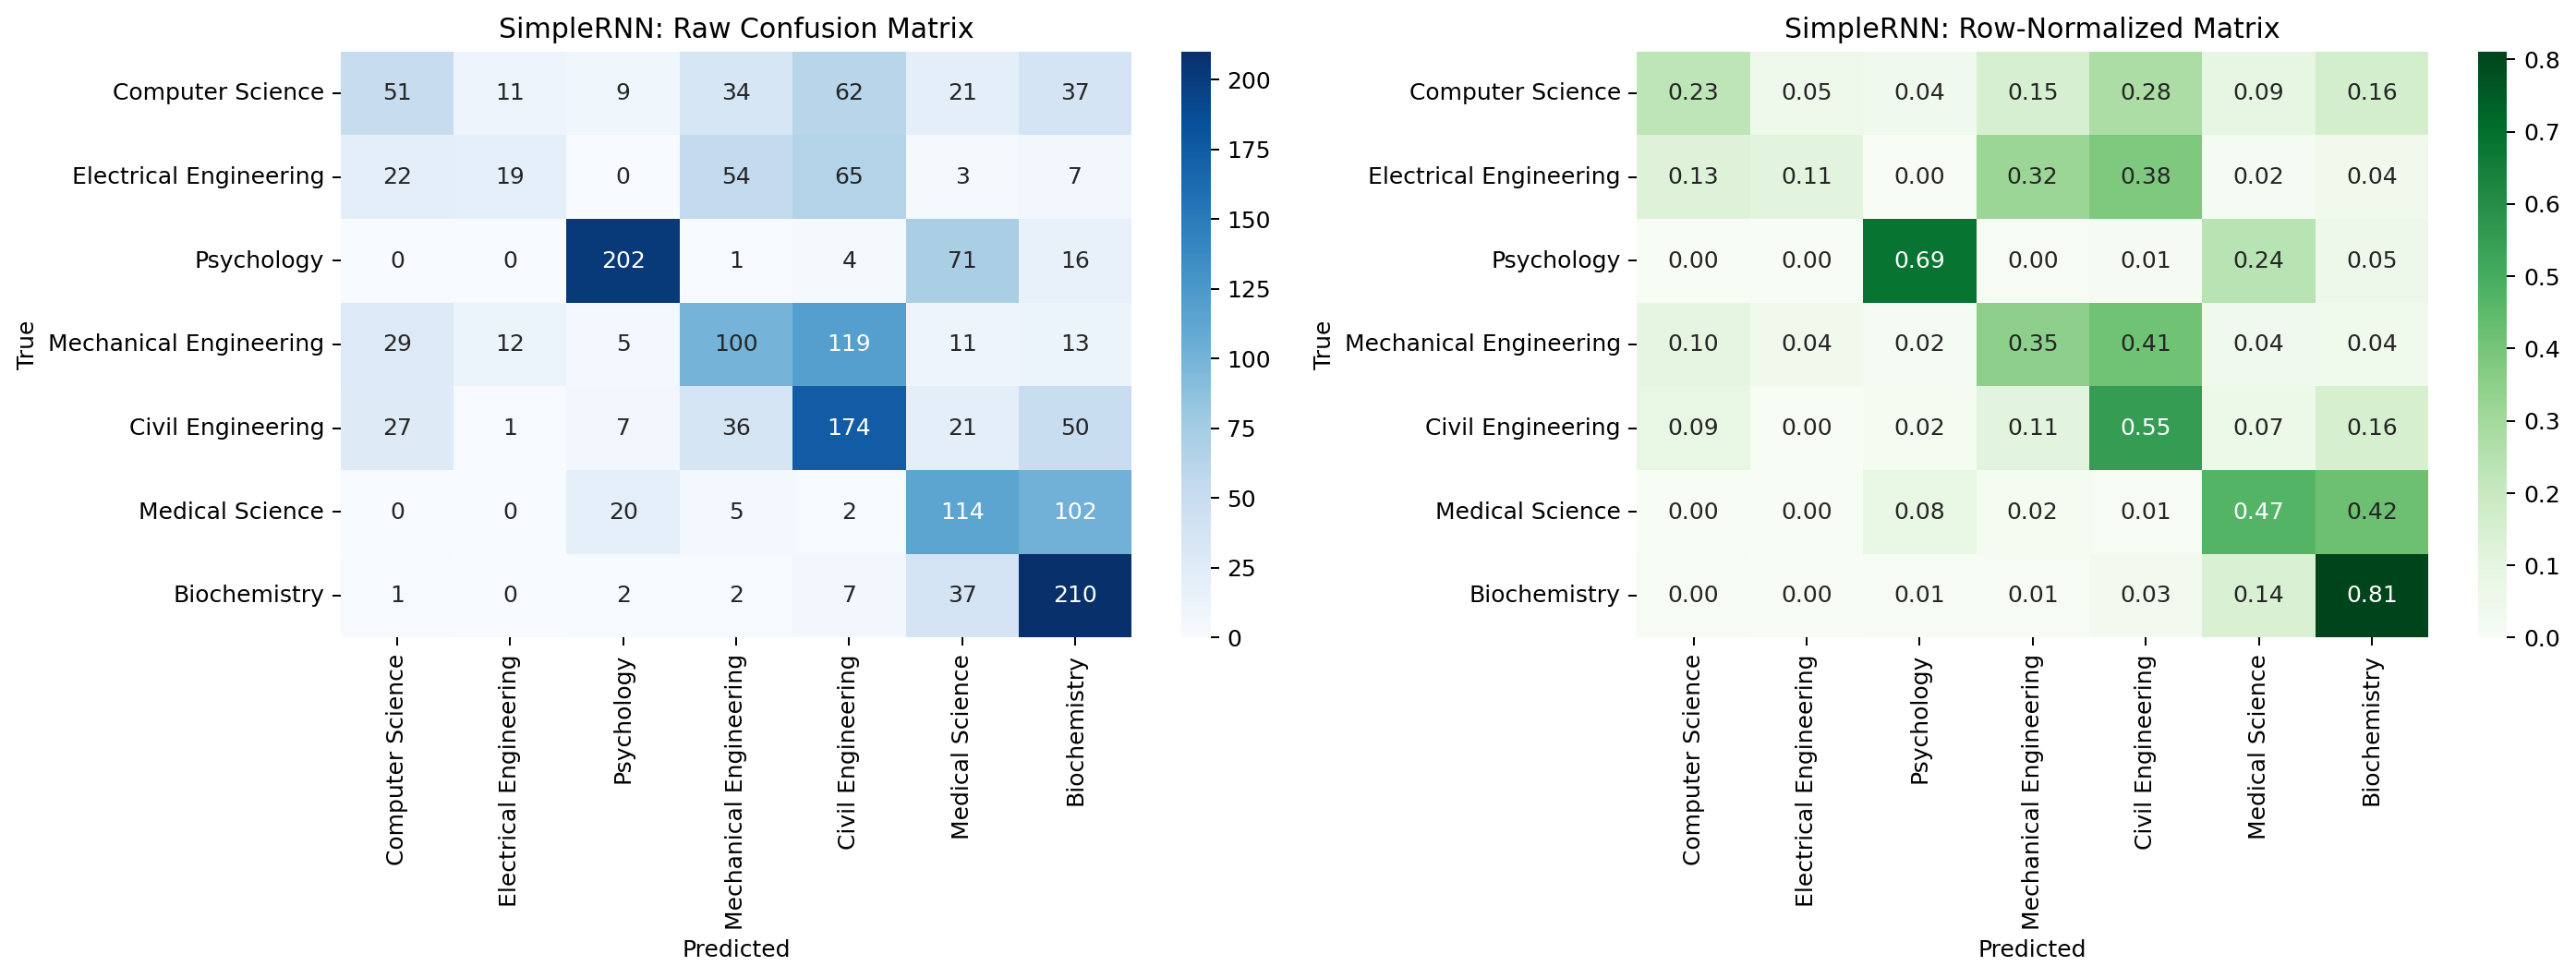

### GRU

,precision,recall,f1-score,support
Computer Science,0.7901,0.8533,0.8205,225.0000
Electrical Engineering,0.9222,0.9059,0.9139,170.0000
Psychology,0.9623,0.8673,0.9123,294.0000
Mechanical Engineering,0.9149,0.8927,0.9037,289.0000
Civil Engineering,0.8997,0.8797,0.8896,316.0000
Medical Science,0.8362,0.7984,0.8168,243.0000
Biochemistry,0.8154,0.9382,0.8725,259.0000
accuracy,0.8764,0.8764,0.8764,0.8764
macro avg,0.8773,0.8765,0.8756,1796.0000
weighted avg,0.8800,0.8764,0.8769,1796.0000


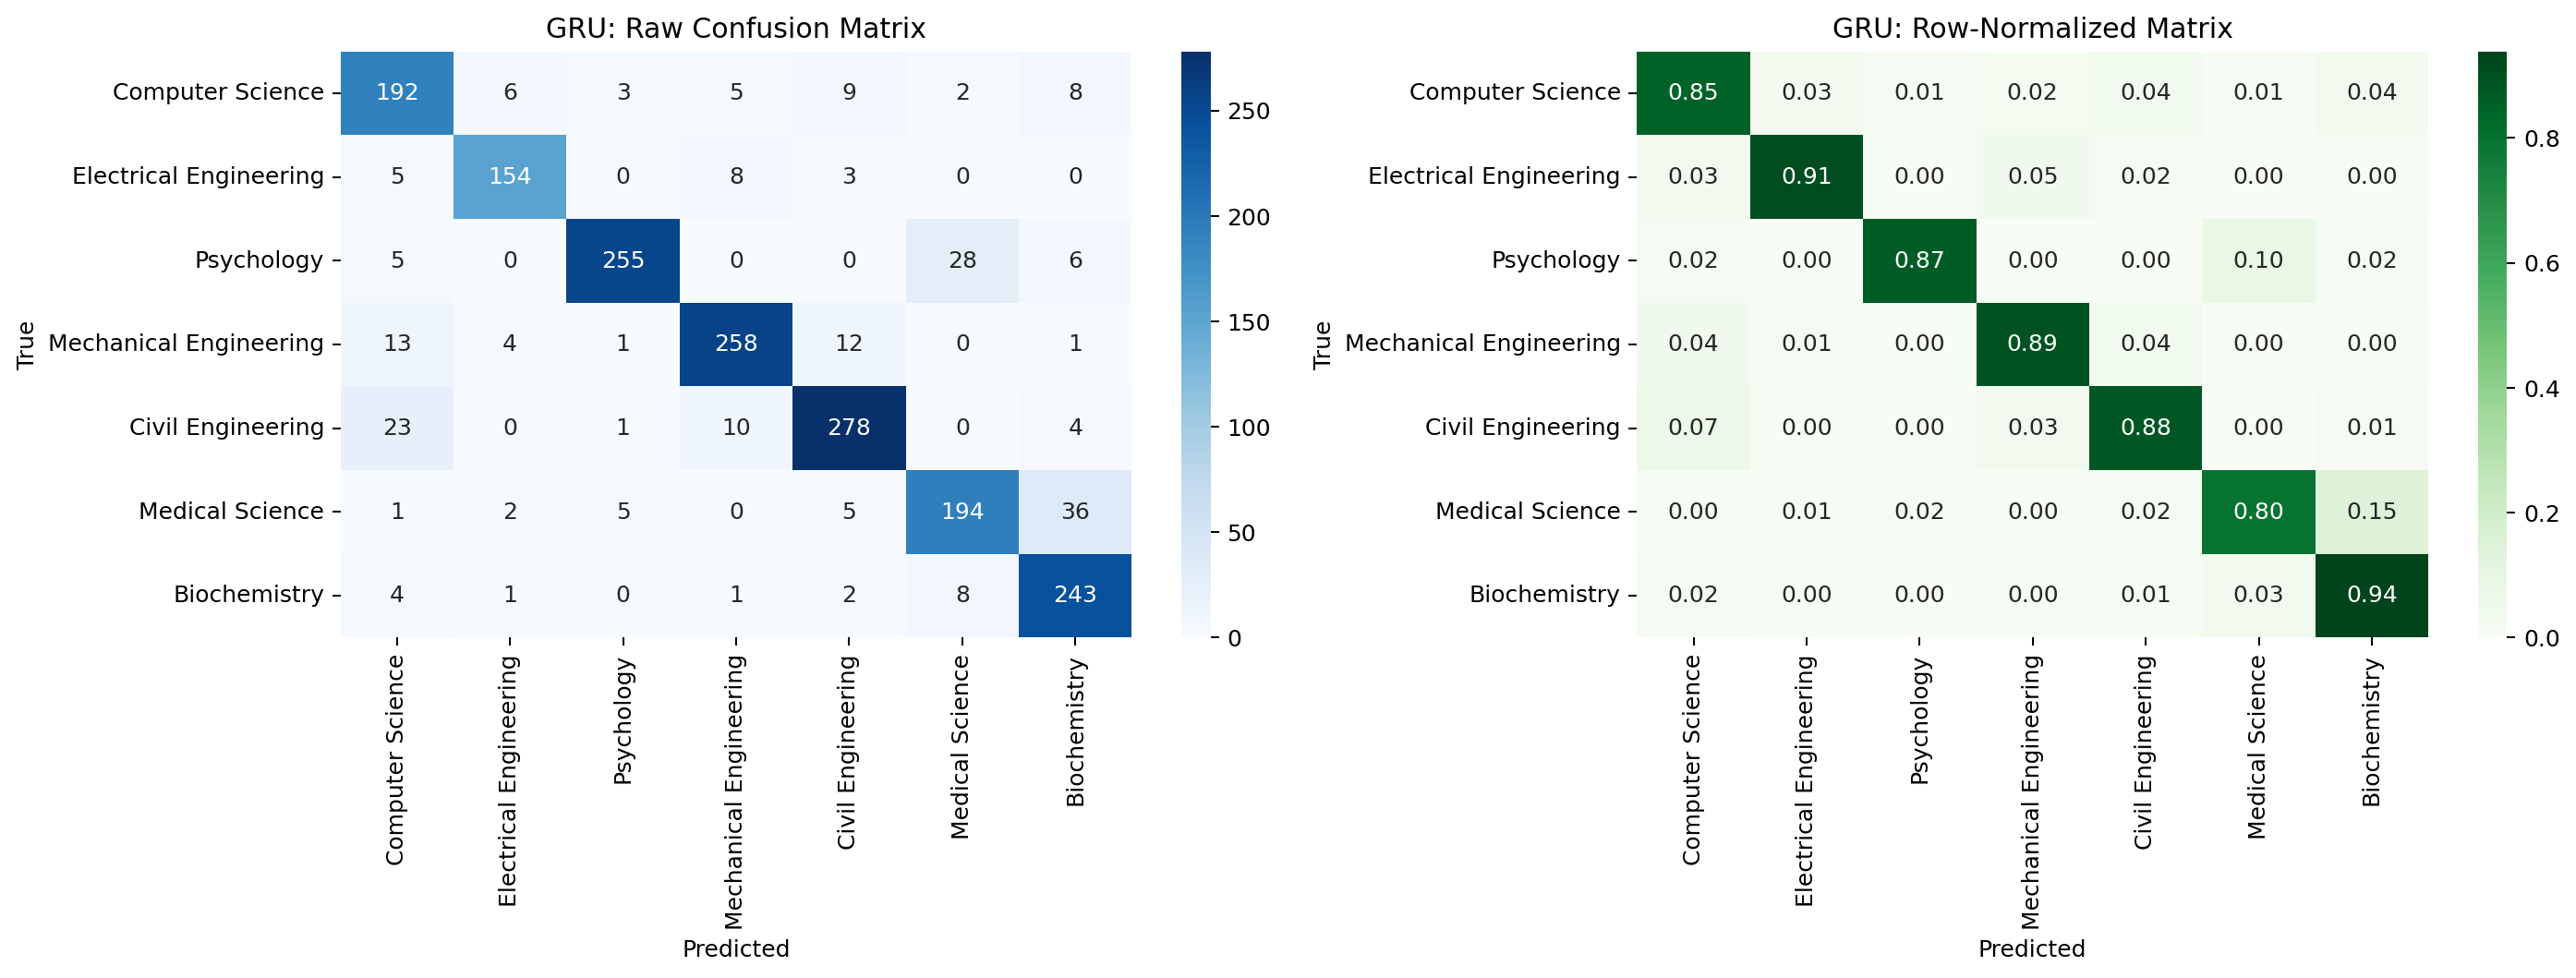

### LSTM

,precision,recall,f1-score,support
Computer Science,0.7948,0.8089,0.8018,225.0000
Electrical Engineering,0.8596,0.8647,0.8622,170.0000
Psychology,0.9574,0.8401,0.8949,294.0000
Mechanical Engineering,0.8708,0.8166,0.8429,289.0000
Civil Engineering,0.8462,0.8703,0.8580,316.0000
Medical Science,0.7879,0.8560,0.8205,243.0000
Biochemistry,0.8237,0.8842,0.8529,259.0000
accuracy,0.8486,0.8486,0.8486,0.8486
macro avg,0.8486,0.8487,0.8476,1796.0000
weighted avg,0.8521,0.8486,0.8492,1796.0000


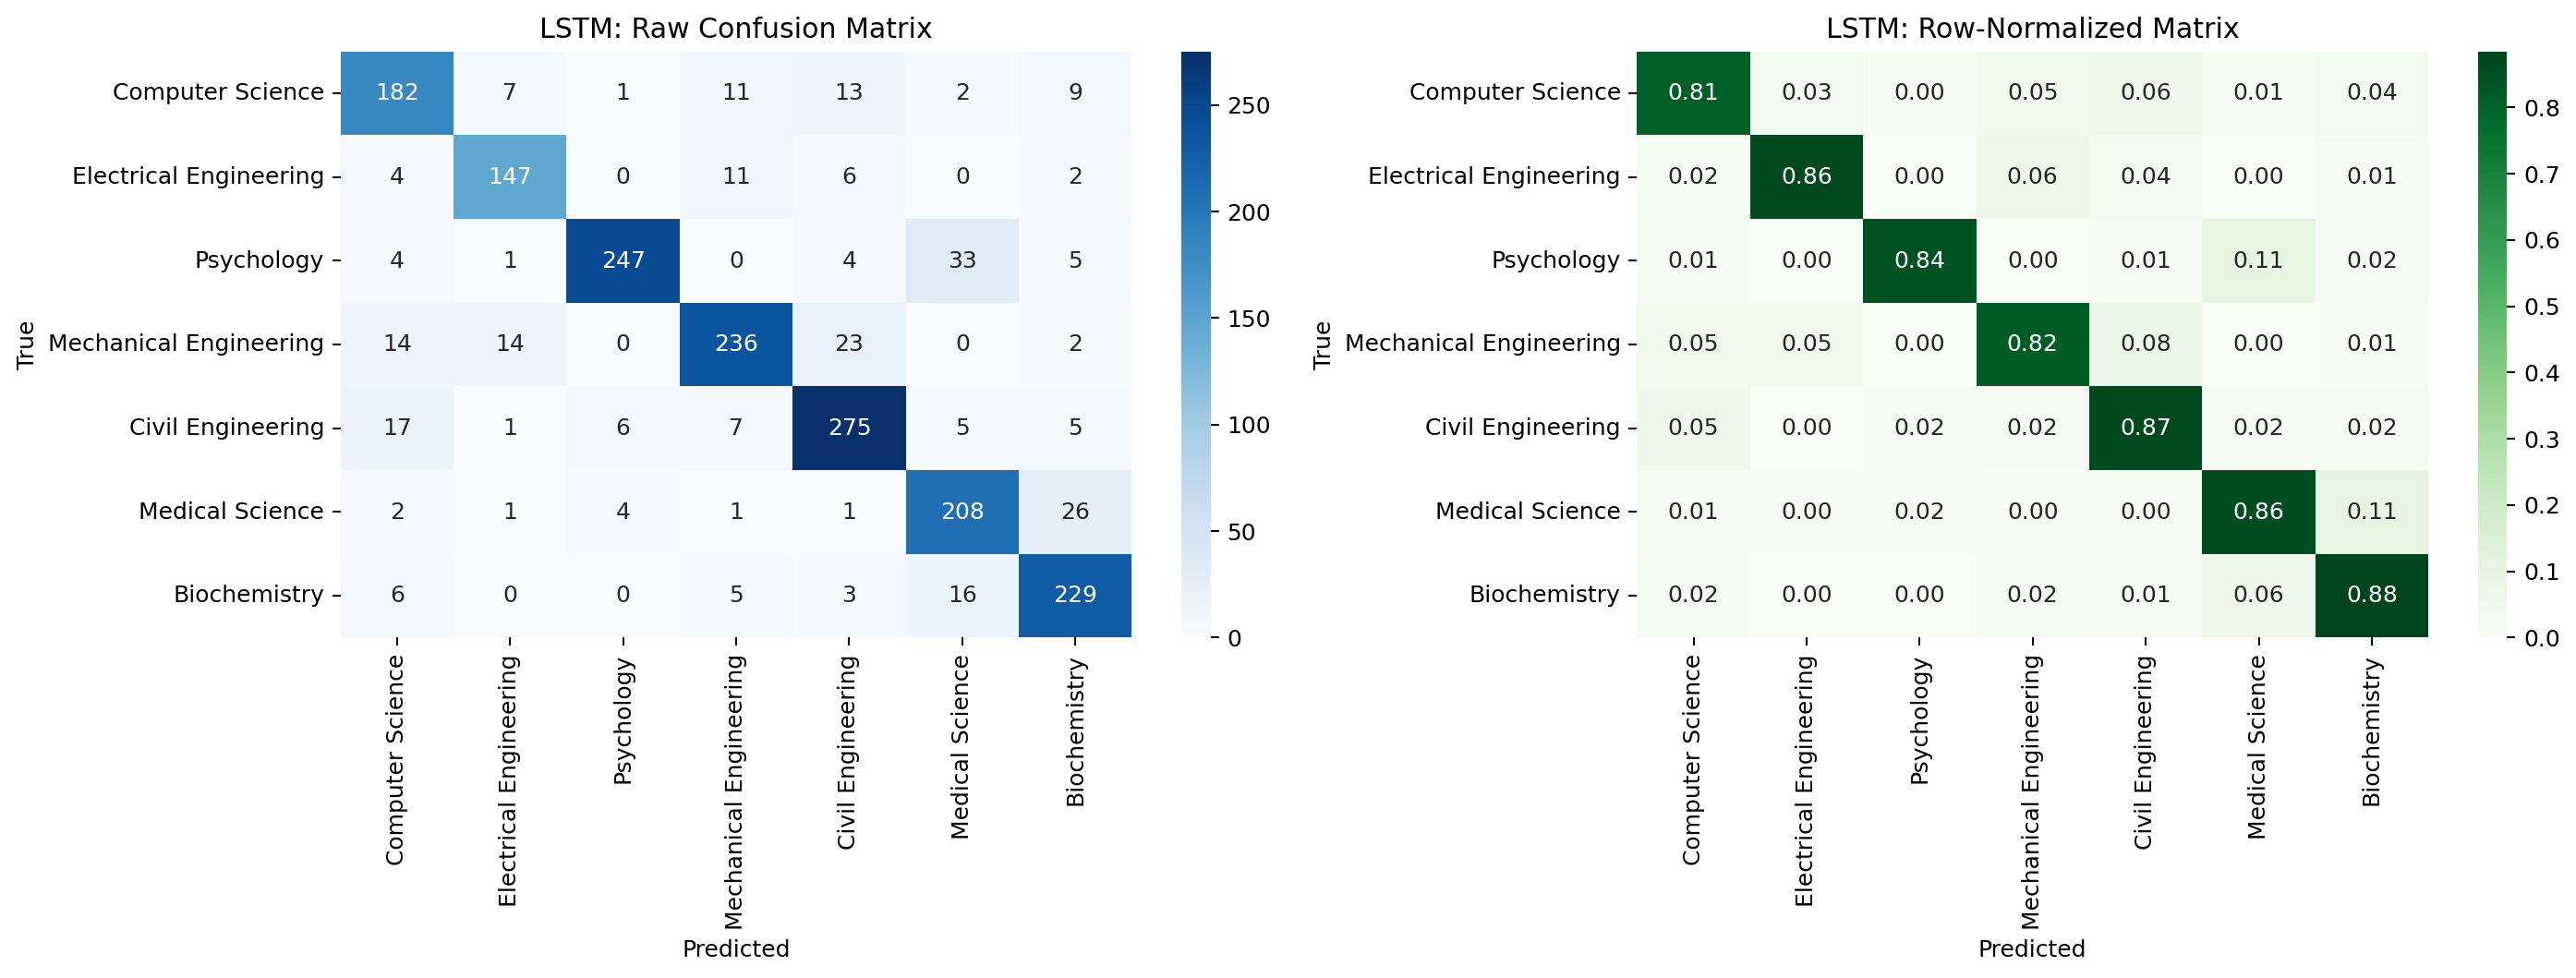

### Bidirectional SimpleRNN

,precision,recall,f1-score,support
Computer Science,0.8081,0.7111,0.7565,225.00
Electrical Engineering,0.8090,0.4235,0.5560,170.00
Psychology,0.8553,0.8844,0.8696,294.00
Mechanical Engineering,0.6214,0.8235,0.7083,289.00
Civil Engineering,0.7781,0.7437,0.7605,316.00
Medical Science,0.6762,0.5844,0.6269,243.00
Biochemistry,0.6581,0.7876,0.7170,259.00
accuracy,0.7300,0.7300,0.7300,0.73
macro avg,0.7437,0.7083,0.7136,1796.00
weighted avg,0.7411,0.7300,0.7258,1796.00


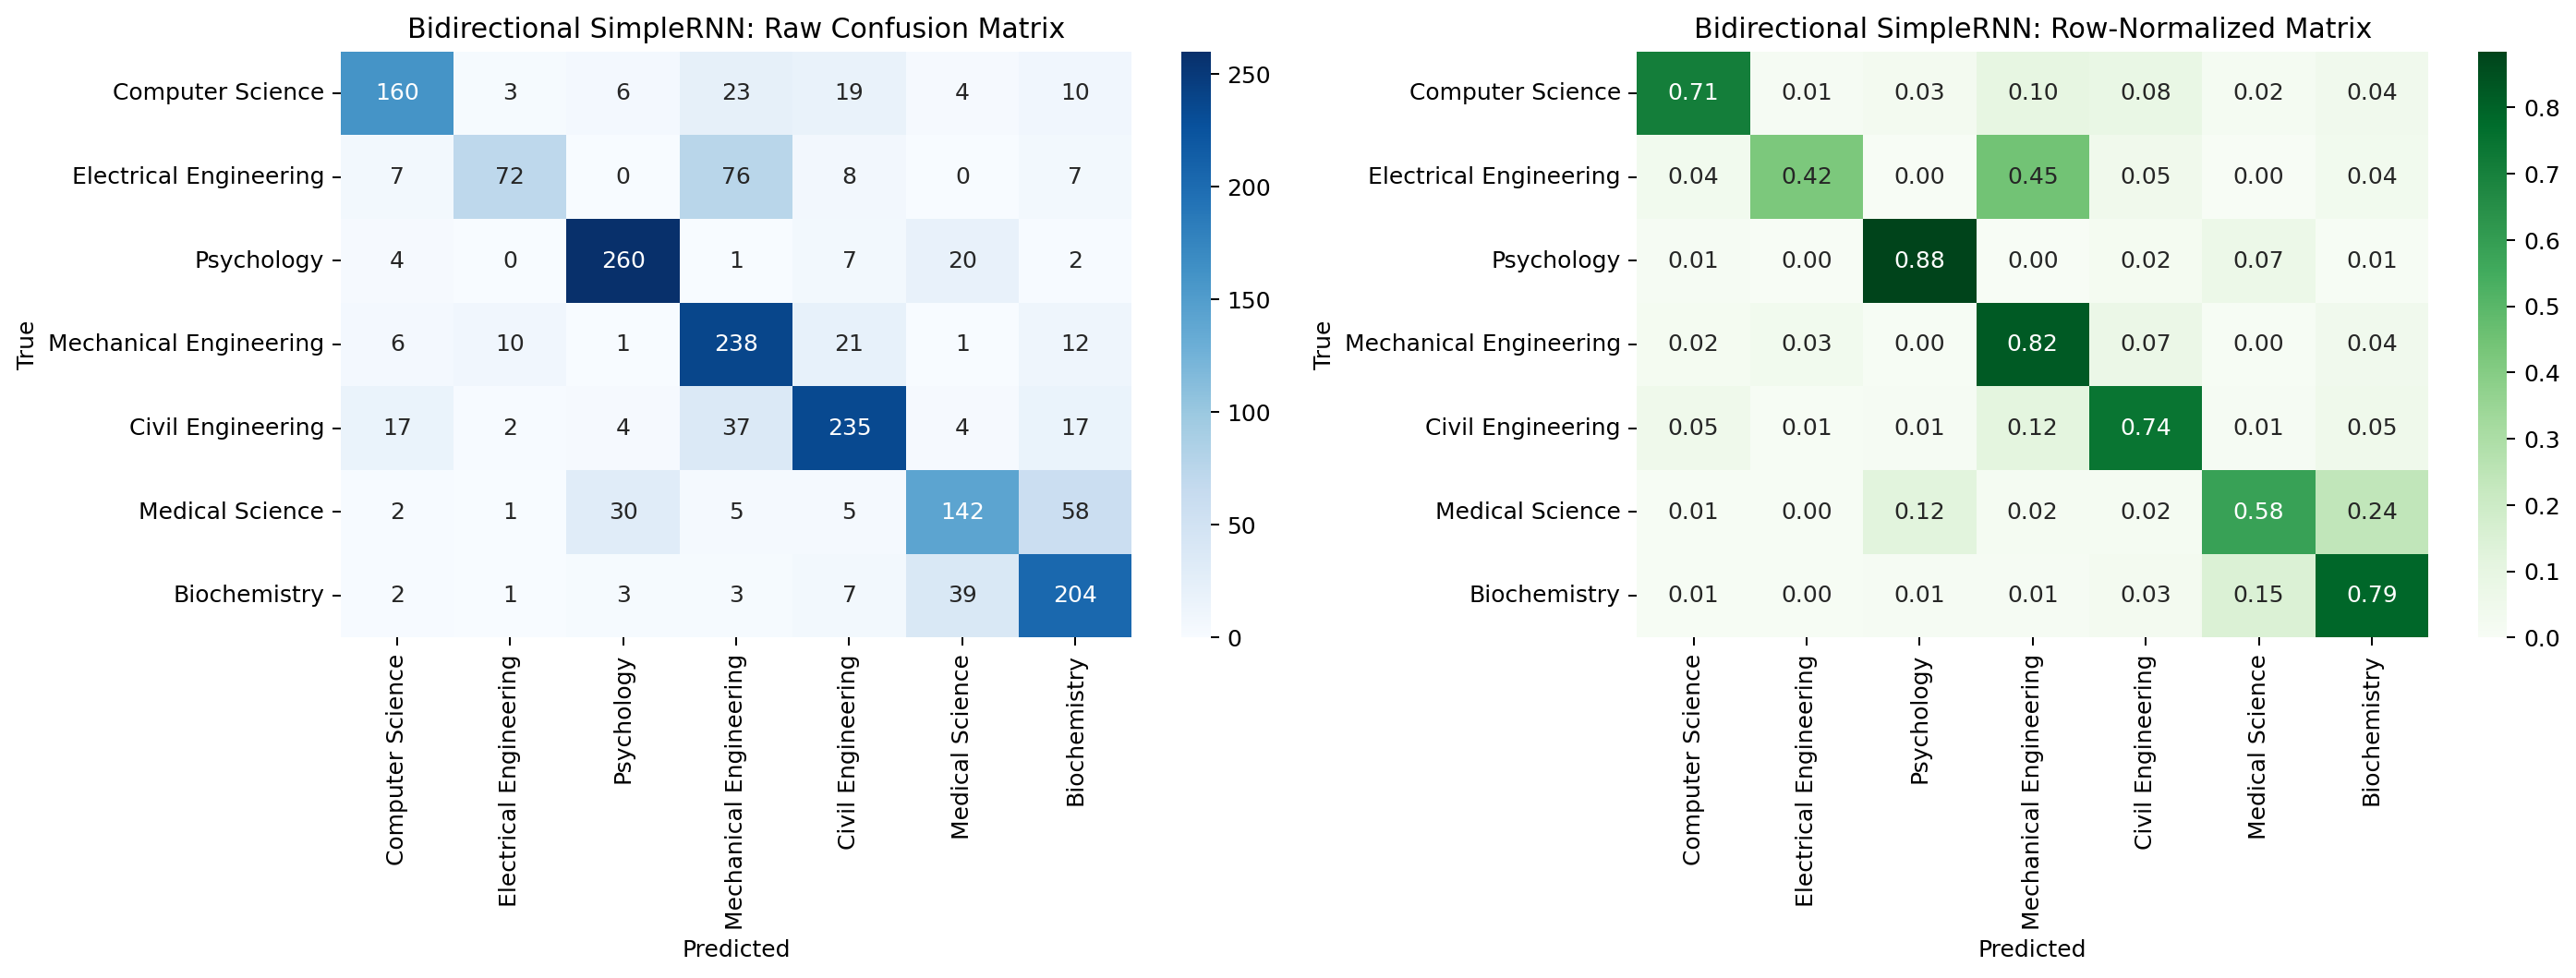

### Bidirectional GRU

,precision,recall,f1-score,support
Computer Science,0.8402,0.9111,0.8742,225.0000
Electrical Engineering,0.9677,0.8824,0.9231,170.0000
Psychology,0.9606,0.9116,0.9354,294.0000
Mechanical Engineering,0.9314,0.8927,0.9117,289.0000
Civil Engineering,0.9000,0.9114,0.9057,316.0000
Medical Science,0.8504,0.8889,0.8692,243.0000
Biochemistry,0.9064,0.9344,0.9202,259.0000
accuracy,0.9059,0.9059,0.9059,0.9059
macro avg,0.9081,0.9046,0.9056,1796.0000
weighted avg,0.9081,0.9059,0.9064,1796.0000


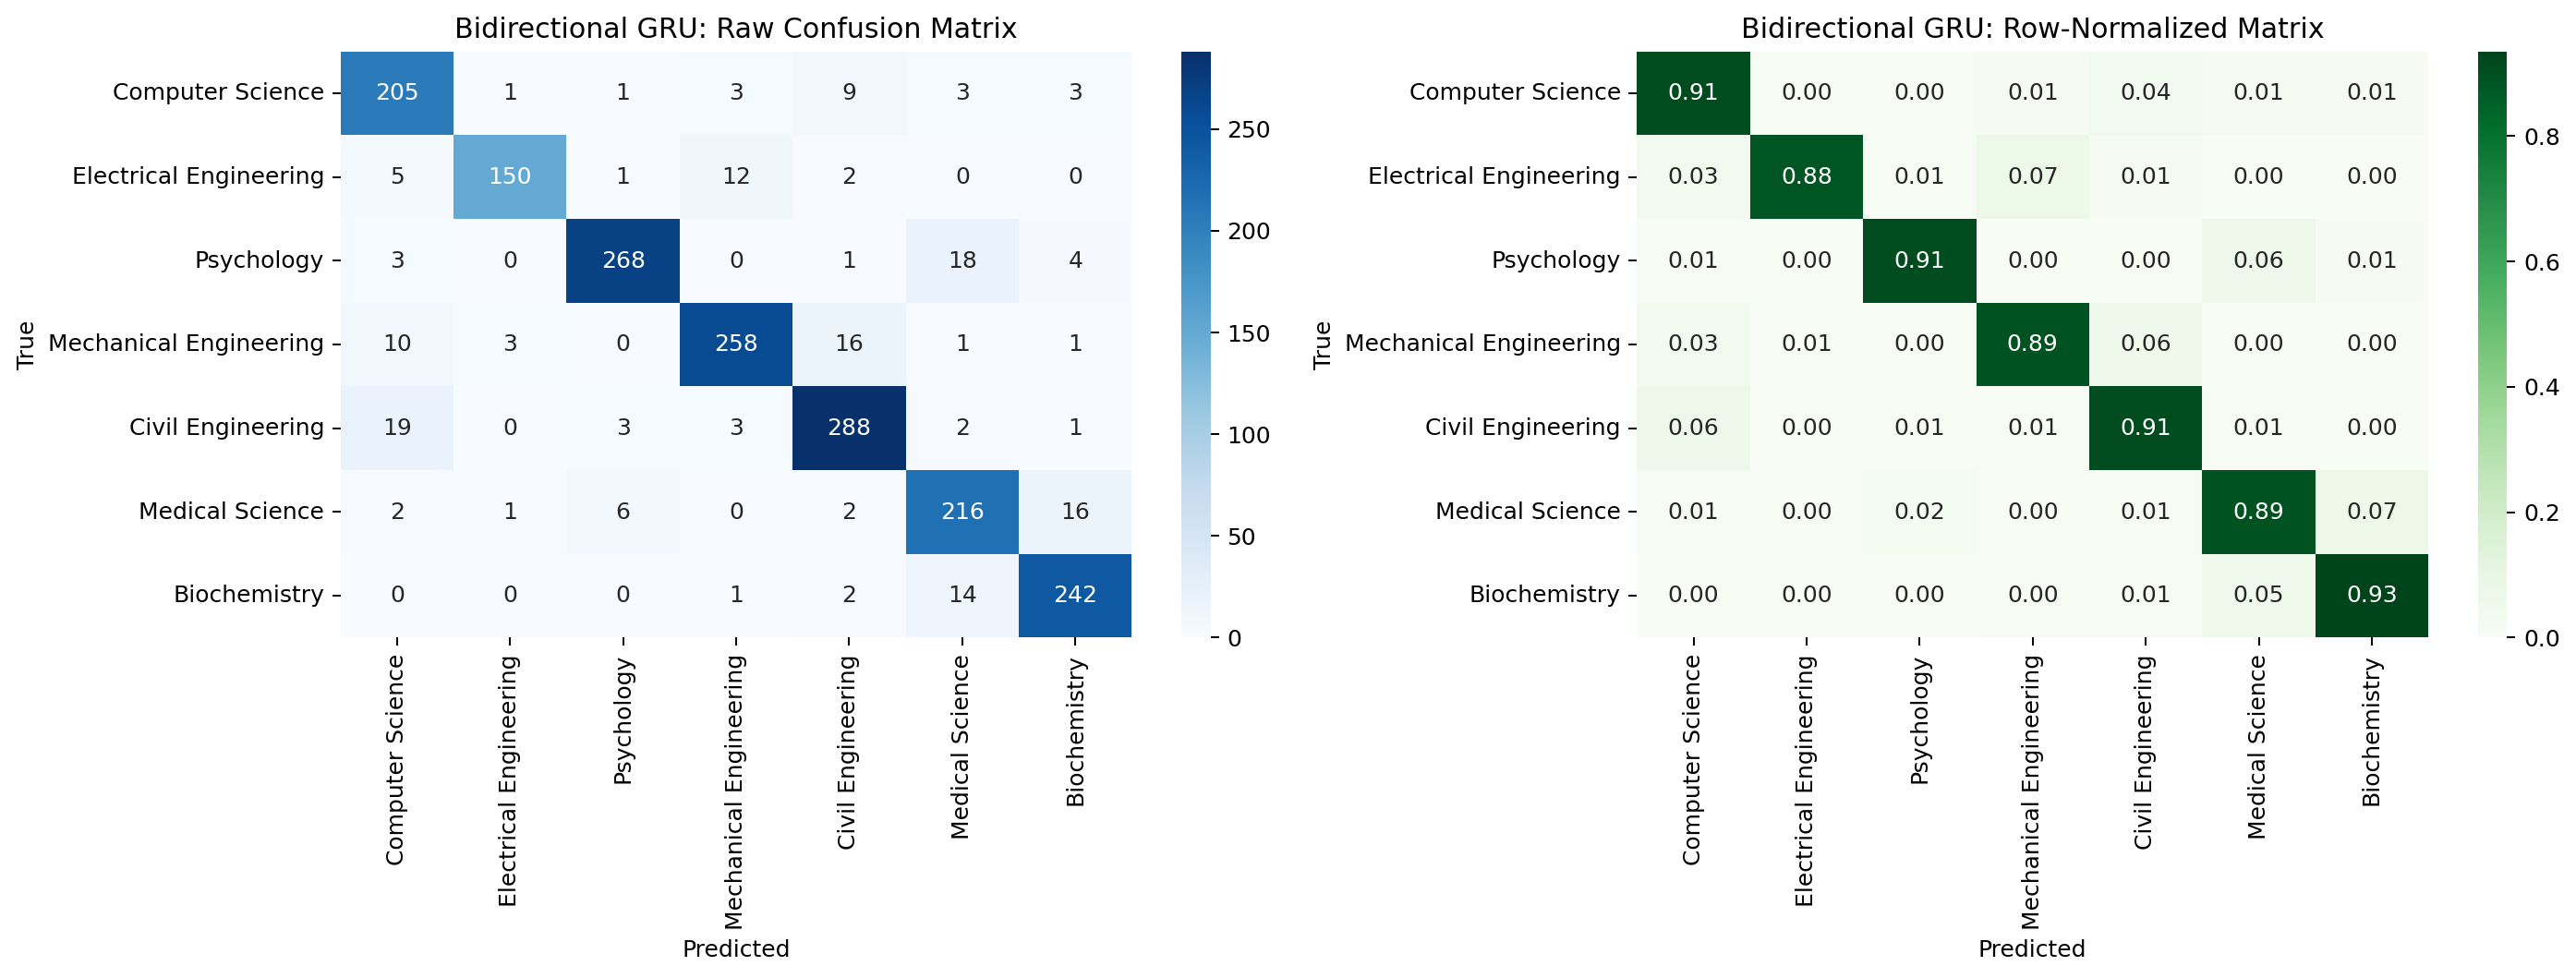

### Bidirectional LSTM

,precision,recall,f1-score,support
Computer Science,0.7311,0.8578,0.7894,225.0000
Electrical Engineering,0.8523,0.8824,0.8671,170.0000
Psychology,0.9611,0.8401,0.8966,294.0000
Mechanical Engineering,0.9019,0.8270,0.8628,289.0000
Civil Engineering,0.8532,0.8829,0.8678,316.0000
Medical Science,0.8211,0.8313,0.8262,243.0000
Biochemistry,0.8467,0.8533,0.8500,259.0000
accuracy,0.8524,0.8524,0.8524,0.8524
macro avg,0.8525,0.8535,0.8514,1796.0000
weighted avg,0.8580,0.8524,0.8536,1796.0000


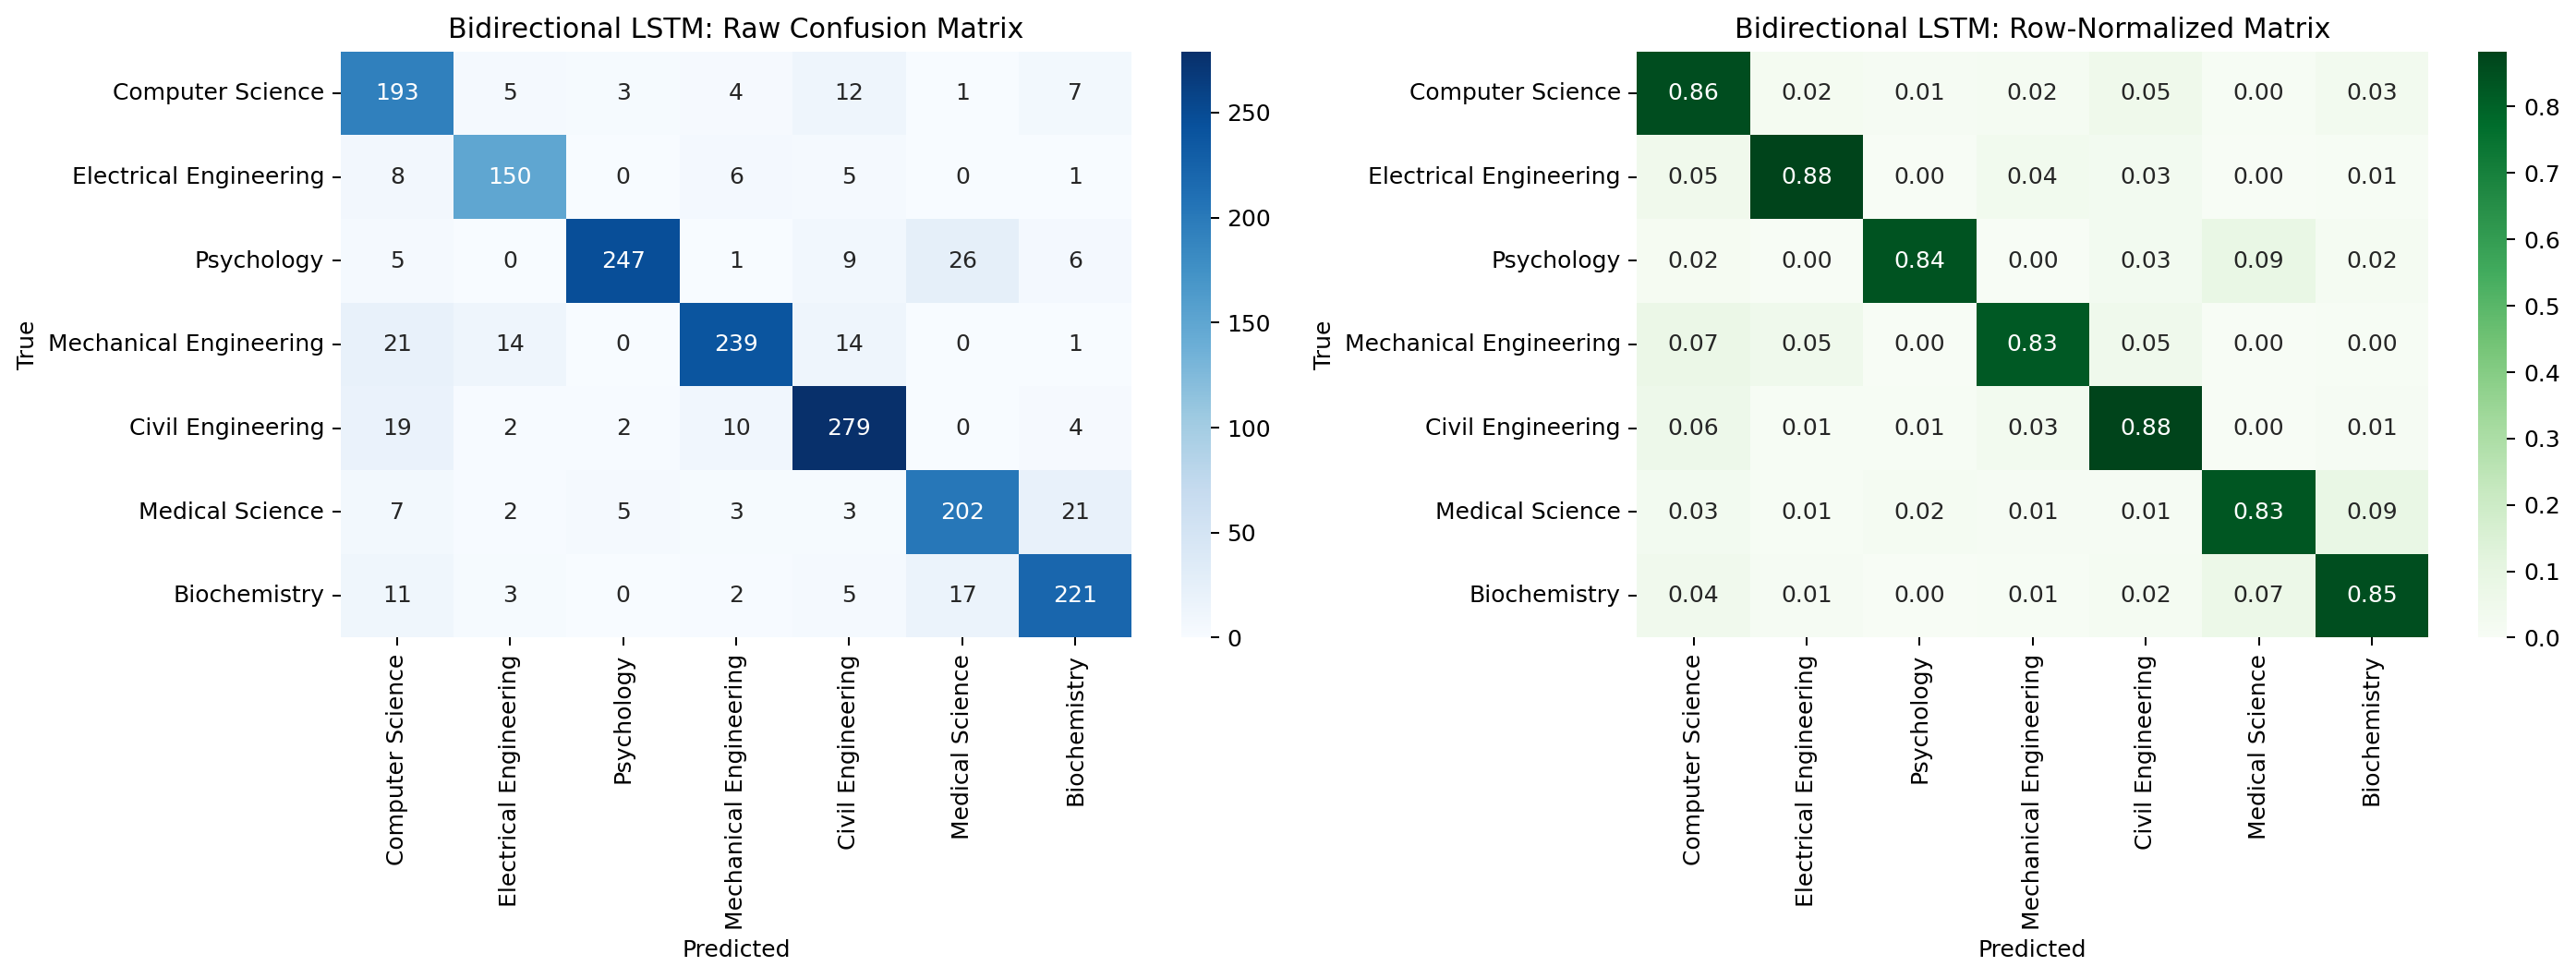

### BERT Base

,precision,recall,f1-score,support
Computer Science,0.9643,0.9600,0.9621,225.0000
Electrical Engineering,0.9576,0.9294,0.9433,170.0000
Psychology,0.9727,0.9694,0.9710,294.0000
Mechanical Engineering,0.9479,0.9446,0.9463,289.0000
Civil Engineering,0.9475,0.9715,0.9594,316.0000
Medical Science,0.9228,0.9342,0.9284,243.0000
Biochemistry,0.9492,0.9382,0.9437,259.0000
accuracy,0.9516,0.9516,0.9516,0.9516
macro avg,0.9517,0.9496,0.9506,1796.0000
weighted avg,0.9517,0.9516,0.9515,1796.0000


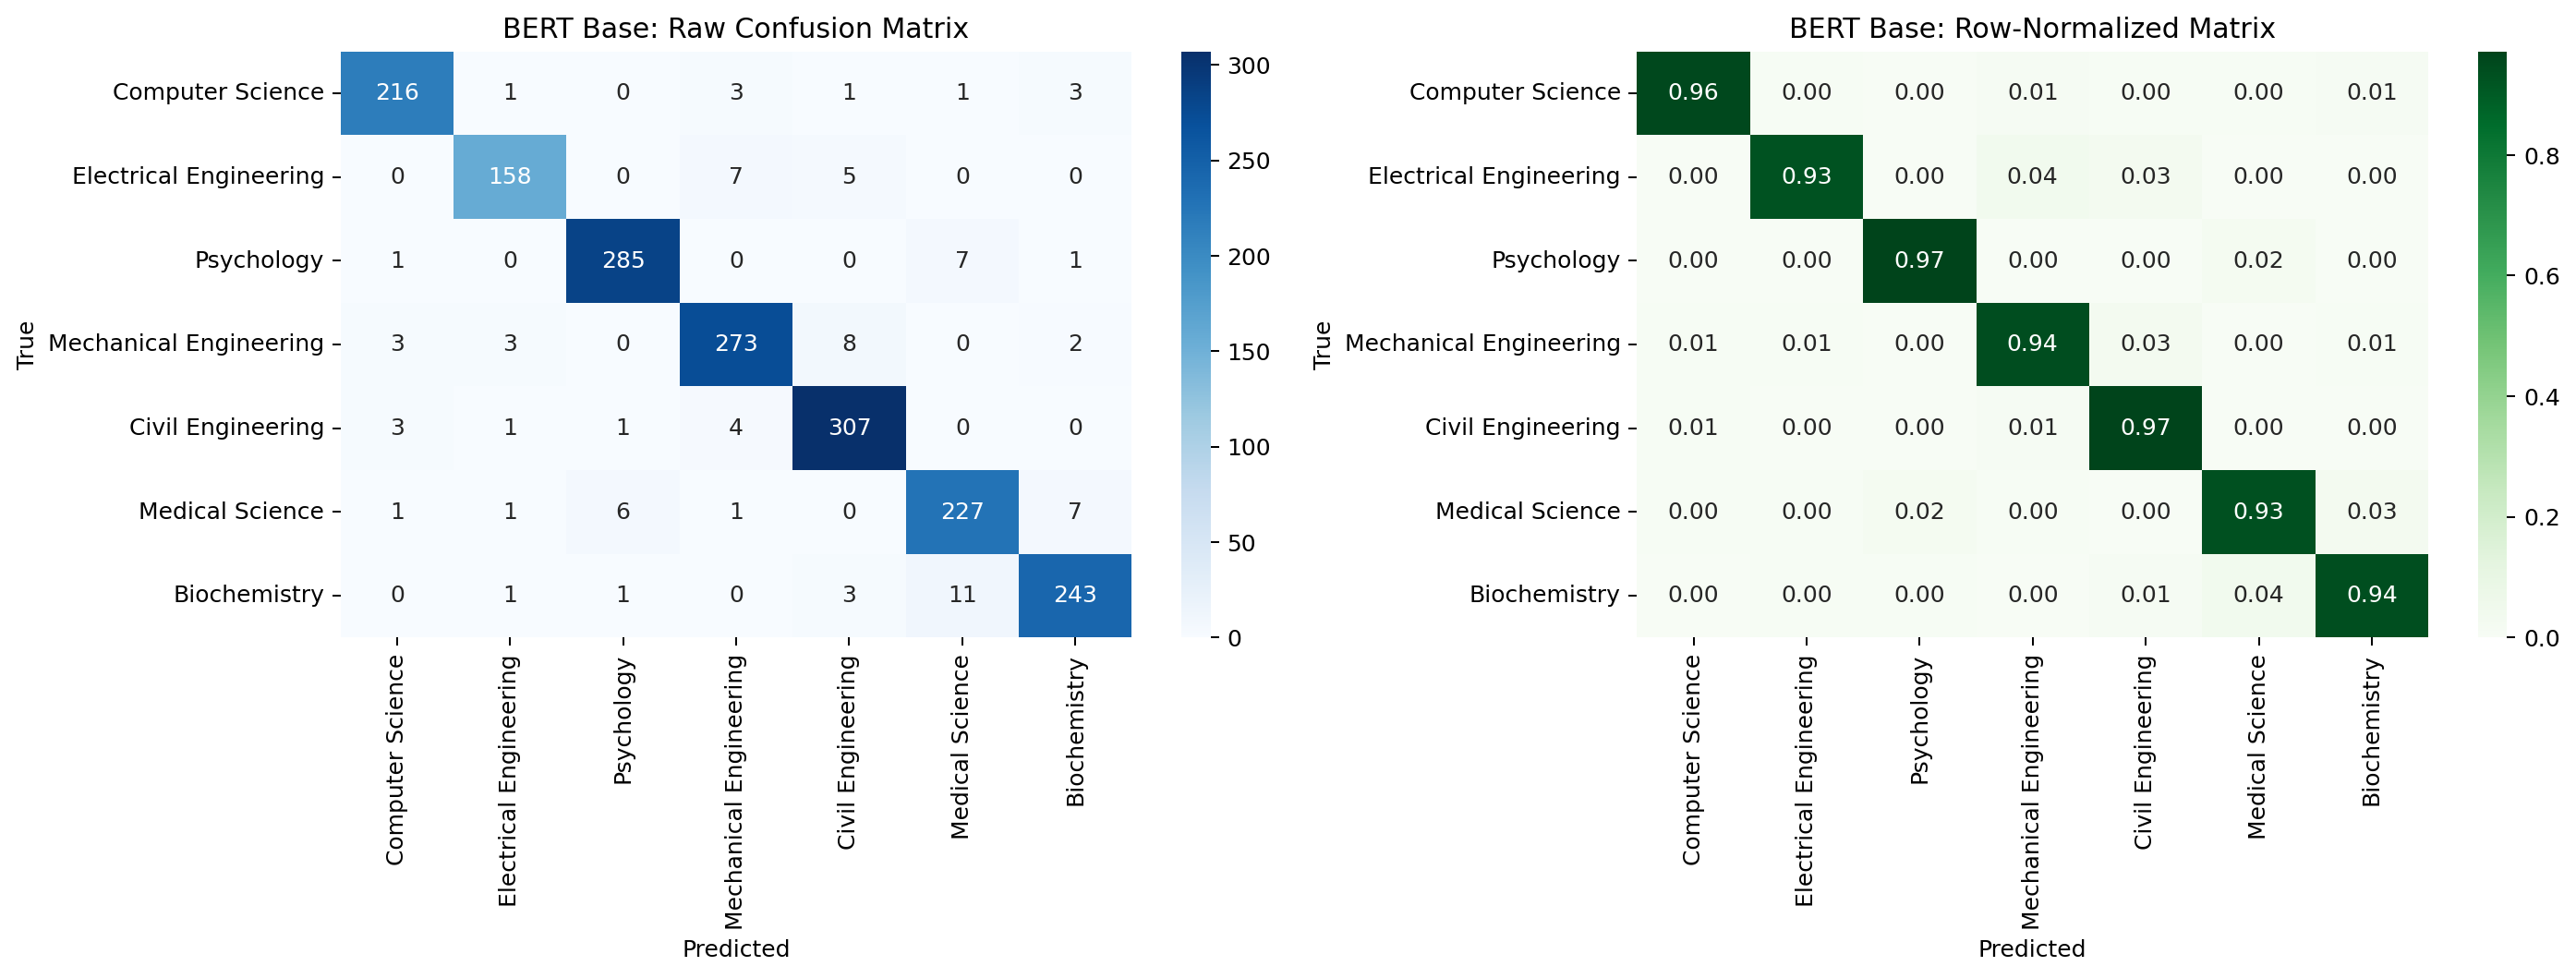

In [107]:
from pathlib import Path
import re
import pandas as pd
from IPython.display import Image, Markdown, display

models_to_display = [
    "Logistic Regression",
    "Multinomial Naive Bayes",
    "Random Forest",
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM",
    "BERT Base",
]

def create_model_slug(model_name):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        model_name.lower(),
    ).strip("_")

def find_saved_file(filename):
    working_matches = list(
        Path("/kaggle/working").rglob(filename)
    )

    if working_matches:
        return working_matches[0]

    input_matches = list(
        Path("/kaggle/input").rglob(filename)
    )

    if input_matches:
        return input_matches[0]

    return None

for model_name in models_to_display:
    slug = create_model_slug(model_name)

    report_filename = f"{slug}_classification_report.csv"
    matrix_filename = f"{slug}_confusion_matrices.png"

    report_path = find_saved_file(report_filename)
    matrix_path = find_saved_file(matrix_filename)

    display(Markdown(f"### {model_name}"))

    if report_path is None:
        print("Classification report not found:", report_filename)
    else:
        classification_report_table = pd.read_csv(
            report_path,
            index_col=0,
        )
        display(classification_report_table.round(4))

    if matrix_path is None:
        print("Confusion matrix not found:", matrix_filename)
    else:
        display(Image(filename=str(matrix_path), width=1100))

## Model Comparison


,model,representation,config_id,accuracy,macro_f1,weighted_f1,training_time_seconds
0,BERT Base,BERT WordPiece,BERT_3,0.951559,0.950603,0.951550,1235.439535
1,Bidirectional GRU,GloVe 6B 100d,B,0.905902,0.905628,0.906365,46.575242
2,Logistic Regression,TF-IDF,LR_3,0.905902,0.902714,0.905592,9.661146
3,Random Forest,TF-IDF,RF_1,0.896437,0.895826,0.896083,10.792903
4,GRU,GloVe 6B 100d,A,0.876392,0.875636,0.876932,34.418817
5,Bidirectional LSTM,GloVe 6B 100d,A,0.852450,0.851396,0.853610,51.676751
6,LSTM,GloVe 6B 100d,B,0.848552,0.847593,0.849154,36.468561
7,Multinomial Naive Bayes,TF-IDF,NB_1,0.842428,0.835756,0.840855,0.040789
8,Bidirectional SimpleRNN,GloVe 6B 100d,C,0.729955,0.713554,0.725765,76.466415
9,SimpleRNN,GloVe 6B 100d,B,0.484410,0.443795,0.465582,28.260609


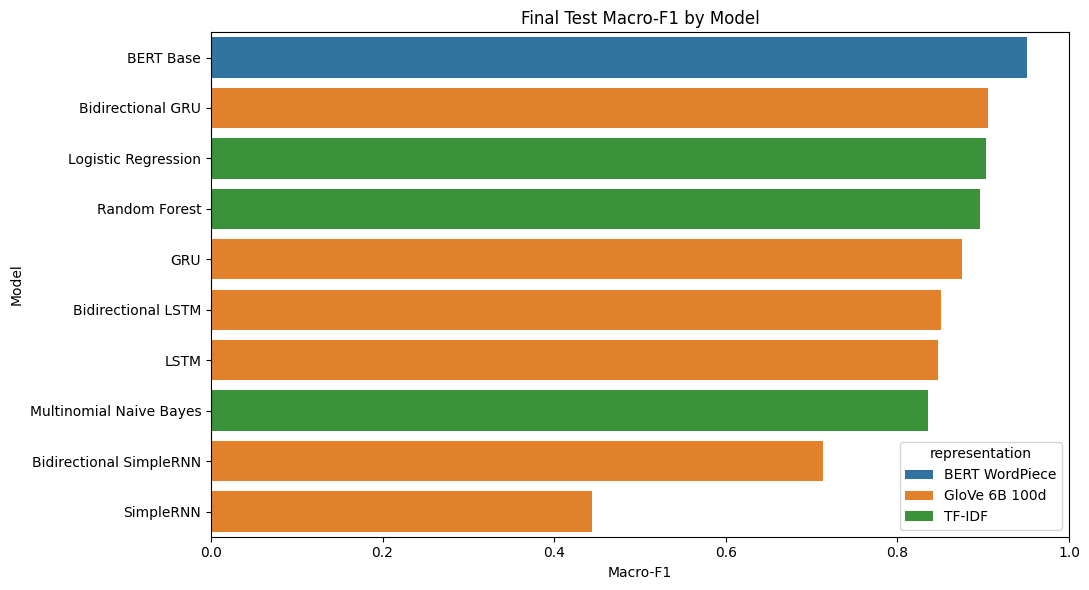

Best model: BERT Base
Worst model: SimpleRNN


In [108]:
if not final_test_results.empty:
    display(final_test_results)

    plt.figure(figsize=(11, 6))
    sns.barplot(data=final_test_results, x="macro_f1", y="model", hue="representation", dodge=False)
    plt.title("Final Test Macro-F1 by Model")
    plt.xlabel("Macro-F1")
    plt.ylabel("Model")
    plt.xlim(0, 1)
    plt.tight_layout()
    comparison_path = FIGURES_DIR / "final_model_comparison.png"
    plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Best model:", final_test_results.iloc[0]["model"])
    print("Worst model:", final_test_results.iloc[-1]["model"])
else:
    print("Run the final stage before creating the model comparison.")


## Error Analysis


In [109]:
confusion_pairs = pd.DataFrame()

if not final_test_results.empty:
    best_model_name = final_test_results.iloc[0]["model"]
    best_predictions = pd.read_csv(PREDICTIONS_DIR / f"{model_slug(best_model_name)}.csv")
    errors = best_predictions.loc[best_predictions["true_label"].ne(best_predictions["predicted_label"])].copy()
    confusion_pairs = (
        errors.groupby(["true_label", "predicted_label"])
        .size()
        .reset_index(name="errors")
        .sort_values("errors", ascending=False)
    )
    confusion_pairs["true_domain"] = confusion_pairs["true_label"].map(label_names)
    confusion_pairs["predicted_domain"] = confusion_pairs["predicted_label"].map(label_names)

    display(confusion_pairs[["true_domain", "predicted_domain", "errors"]].head(10))

    error_examples = errors.merge(test_data[["document_id", "text"]], on="document_id", how="left")
    error_examples["true_domain"] = error_examples["true_label"].map(label_names)
    error_examples["predicted_domain"] = error_examples["predicted_label"].map(label_names)
    error_examples["excerpt"] = error_examples["text"].str.slice(0, 450)
    display(error_examples[["document_id", "true_domain", "predicted_domain", "excerpt"]].head(15))
else:
    print("Error analysis becomes available after final test evaluation.")


,true_domain,predicted_domain,errors
26,Biochemistry,Medical Science,11
12,Mechanical Engineering,Civil Engineering,8
5,Electrical Engineering,Mechanical Engineering,7
8,Psychology,Medical Science,7
22,Medical Science,Biochemistry,7
20,Medical Science,Psychology,6
6,Electrical Engineering,Civil Engineering,5
17,Civil Engineering,Mechanical Engineering,4
10,Mechanical Engineering,Computer Science,3
1,Computer Science,Mechanical Engineering,3


,document_id,true_domain,predicted_domain,excerpt
0,wos11967_v6_00121,Computer Science,Mechanical Engineering,The screening of a number of chiral stationary...
1,wos11967_v6_00365,Biochemistry,Medical Science,Compelling evidences point out a crucial role ...
2,wos11967_v6_00427,Biochemistry,Electrical Engineering,"In this paper, we analyse the local stability ..."
3,wos11967_v6_00457,Mechanical Engineering,Civil Engineering,Heating of groundwater by thermal energy stora...
4,wos11967_v6_00751,Mechanical Engineering,Computer Science,This paper introduces the main topics related ...
5,wos11967_v6_00775,Psychology,Medical Science,The games that adolescents and young people us...
6,wos11967_v6_00841,Electrical Engineering,Mechanical Engineering,"After its recent improvements described here, ..."
7,wos11967_v6_01082,Computer Science,Biochemistry,Bacterial nanocellulose (BNC) is an emerging n...
8,wos11967_v6_01151,Psychology,Medical Science,Anorexia nervosa (AN) is an illness that frequ...
9,wos11967_v6_01382,Electrical Engineering,Mechanical Engineering,This paper presents an experimental investigat...


# 12. Research Questions, Limitations, and Conclusion

In [110]:
if not final_test_results.empty:
    traditional_results = final_test_results.loc[final_test_results["model"].isin([
        "Logistic Regression", "Multinomial Naive Bayes", "Random Forest"
    ])]
    recurrent_results = final_test_results.loc[final_test_results["model"].isin(recurrent_models)]
    bert_result = final_test_results.loc[final_test_results["model"].eq("BERT Base")].iloc[0]

    rq_evidence = pd.DataFrame({
        "Research question": ["RQ1", "RQ2", "RQ3", "RQ4"],
        "Evidence": [
            f"Best traditional model: {traditional_results.iloc[0]['model']} with macro-F1 {traditional_results.iloc[0]['macro_f1']:.4f}",
            f"Best recurrent model: {recurrent_results.iloc[0]['model']} with macro-F1 {recurrent_results.iloc[0]['macro_f1']:.4f}",
            f"BERT macro-F1 {bert_result['macro_f1']:.4f}; best non-BERT macro-F1 {final_test_results.loc[final_test_results['model'].ne('BERT Base'), 'macro_f1'].max():.4f}",
            "Most common confusion: " + (
                f"{confusion_pairs.iloc[0]['true_domain']} to {confusion_pairs.iloc[0]['predicted_domain']}"
                if not confusion_pairs.empty else "No errors"
            ),
        ],
    })
    display(rq_evidence)
else:
    print("Research-question evidence becomes available after final test evaluation.")


,Research question,Evidence
0,RQ1,Best traditional model: Logistic Regression wi...
1,RQ2,Best recurrent model: Bidirectional GRU with m...
2,RQ3,BERT macro-F1 0.9506; best non-BERT macro-F1 0...
3,RQ4,Most common confusion: Biochemistry to Medical...


## Final interpretation

BERT Base achieved 0.950603 test macro-F1 and 0.951559 accuracy. Bidirectional GRU was the best recurrent model (0.905628 macro-F1); Logistic Regression was the strongest TF-IDF baseline (0.902714). BERT improved macro-F1 over the strongest non-BERT model by about 4.50 percentage points.

The most frequent BERT error was Biochemistry predicted as Medical Science (11 examples). Shared terminology and interdisciplinary abstracts are plausible explanations, not independently established causes. Results use one fixed split and seed; repeated-seed uncertainty and external-dataset generalization were not measured. Recorded tuning-run times are not inference-latency measurements.
